# Load modules

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import os
import numpy as np
from shapely.geometry import Polygon

In [2]:
rc = lambda r,c:pl.Config(set_tbl_rows=r,set_tbl_cols=c)

In [3]:
project_name='240510 wide temp'
if not os.path.exists('plots/'+project_name):
    os.mkdir('plots/'+project_name)
if not os.path.exists('Processed data/'+project_name):
    os.mkdir('Processed data/'+project_name)
if not os.path.exists('Raw data/'+project_name):
    os.mkdir('Raw data/'+project_name)

# Load data

## Batch files

In [4]:
def read_batch_file(path):
    start = pl.read_csv(path).with_row_index().filter(pl.col('[Header]')=='[Batch Table]')['index'][0]+2
    nrows = int(pl.read_csv(path,
                skip_rows=start,has_header=False,n_rows=1)[0,0].split('\t')[-1])
    return pl.read_csv(path,
                skip_rows=start+1,has_header=True,n_rows=nrows,separator='\t')

In [5]:
b0 = read_batch_file('Processed data/batch files/240428-std curve.txt')
b1 = read_batch_file('Processed data/batch files/240510 WideTempSol QC.txt')
b2 = read_batch_file('Processed data/batch files/240510 WideTempSol t1(65h).txt')
b3 = read_batch_file('Processed data/batch files/240510 WideTempSol t2(5days).txt')
batch = pl.concat([b0,b1,b2,b3])
batch

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data File,Background,Background Data File,Level#,Inj. Volume,ISTD Amt.,Sample Amt.,Dil. Factor,System Check,Report Output,Report Format File,User Prog.,Action,Data Comment,AutoPurge,Baseline Check,Option 1,Option 2,Option 3,Option 4,Option 5,Custom Parameters,Auto Tuning,Tuning File,PsiPort Instrument Method File,Summary Type,Summary Report Format File,Option 6,Option 7,Option 8,Option 9,Option 10,System Suitability,Multi Injection,Barcode,Sampler File,Conc. Overrides
str,str,str,str,i64,str,str,str,str,i64,str,i64,f64,str,i64,i64,str,i64,str,str,str,str,i64,i64,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,i64,i64,str,str,str
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""A2""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard:(I)""",null,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.33pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…",0,null,2,9.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DL AQ DP""","""1""","""C11""","""23 deg buffer""",16,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t2(5days)_2…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""D11""","""30 deg buffer""",17,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t2(5days)_3…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""E11""","""40 deg buffer""",18,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t2(5days)_4…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null


In [6]:
batch=batch.rename({'Data File':'Data Filename'})

## UV

In [7]:
summary205 = pl.read_csv('Processed data/240510 wide temp/All 205nm reprocessed 260120.txt',
                         skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summary205

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str
1,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.395,1872.0,0.079,1227.0,0.11,72.1,"""*""",4.362,4.445,0.03,29.01,"""1.099"""
2,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.397,2086.0,0.088,1277.0,0.11,79.8,"""*""",4.347,4.435,0.04,24.76,"""1.176"""
3,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.412,9363.0,0.375,4412.0,0.33,113.6,"""*""",4.357,4.545,0.04,93.19,"""1.737"""
4,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.407,9840.0,0.394,4726.0,0.33,119.3,"""*""",4.33,4.488,0.04,112.1,"""1.024"""
5,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.41,26119.0,1.036,13193.0,1.0,103.6,"""*""",4.34,4.492,0.04,275.81,"""0.964"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
67,"""240510 WideTempSol QC_buffer24…","""Control""","""buffer240510""","""A1""",null,null,null,null,null,null,null,null,null,null,null,null
68,"""240510 WideTempSol QC_10uM ABm…","""Unknown""","""10uM ABm1-42""","""B1""",4.407,176389.0,6.962,77684.0,null,null,null,4.152,4.638,0.05,1506.97,"""0.976"""
69,"""240510 WideTempSol QC_10uM ABm…","""Unknown""","""10uM ABm1-42""","""B1""",4.41,172731.0,6.818,76782.0,null,null,null,4.102,4.577,0.05,1262.51,"""1.008"""


In [8]:
pl.concat([batch,summary205],how='align_full').drop_nulls('Inj. Volume')#.drop_nulls('Area')

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data Filename,Background,Background Data File,Level#,Inj. Volume,ISTD Amt.,Sample Amt.,Dil. Factor,System Check,Report Output,Report Format File,User Prog.,Action,Data Comment,AutoPurge,Baseline Check,Option 1,Option 2,Option 3,Option 4,Option 5,Custom Parameters,Auto Tuning,Tuning File,PsiPort Instrument Method File,Summary Type,Summary Report Format File,Option 6,Option 7,Option 8,Option 9,Option 10,System Suitability,Multi Injection,Barcode,Sampler File,Conc. Overrides,,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
str,str,str,str,i64,str,str,str,str,i64,str,i64,f64,str,i64,i64,str,i64,str,str,str,str,i64,i64,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,i64,i64,str,str,str,i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_none_001…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_none_001…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_non…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DL AQ DP""","""1""","""F3""","""70deg""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_70d…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""F4""","""70deg""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_70d…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""F5""","""70deg-buffer""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_70d…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,""

In [9]:
batch.columns

['Run Mode',
 'Tray Name',
 'Vial#',
 'Sample Name',
 'Sample ID',
 'Sample Type',
 'Analysis Type',
 'Method File',
 'Data Filename',
 'Background',
 'Background Data File',
 'Level#',
 'Inj. Volume',
 'ISTD Amt.',
 'Sample Amt.',
 'Dil. Factor',
 'System Check',
 'Report Output',
 'Report Format File',
 'User Prog.',
 'Action',
 'Data Comment',
 'AutoPurge',
 'Baseline Check',
 'Option 1',
 'Option 2',
 'Option 3',
 'Option 4',
 'Option 5',
 'Custom Parameters',
 'Auto Tuning',
 'Tuning File',
 'PsiPort Instrument Method File',
 'Summary Type',
 'Summary Report Format File',
 'Option 6',
 'Option 7',
 'Option 8',
 'Option 9',
 'Option 10',
 'System Suitability',
 'Multi Injection',
 'Barcode',
 'Sampler File',
 'Conc. Overrides']

In [10]:
summary205.columns

['',
 'Data Filename',
 'Sample Type',
 'Sample Name',
 'Vial#',
 'Ret. Time',
 'Area',
 'Conc.',
 'Height',
 'Std. Conc.',
 'Accuracy[%]',
 'Cal. Point',
 'Peak Start',
 'Peak End',
 'Quant. Limit(QL)',
 'S/N',
 'Tailing F.']

In [11]:
UV = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summary205.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
UV

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_none_001…","""Control""",4.413,308111.0,12.157,21701.0,4.213,4.652,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_none_001…","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_non…","""Control""",null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…
"""F3""","""70deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_70d…","""Unknown""",4.408,209004.0,8.249,36539.0,3.963,4.603,null
"""F4""","""70deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_70d…","""Unknown""",4.395,317609.0,12.532,51935.0,3.925,4.805,null
"""F5""","""70deg-buffer""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_70d…","""Unknown""",4.437,40598.0,1.607,11766.0,4.34,4.635,null


In [12]:
rc(20,20)

In [13]:
UV.filter(pl.col('Sample Name').str.contains('10uM'))#.filter(pl.col('Sample Name').str.contains('buffer')).mean()

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.408,166353.0,6.566,74926.0,4.157,4.647,null
"""B1""","""10uM ABm1-42""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.393,1.70879e6,67.401,712108.0,4.15,4.665,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.41,172731.0,6.818,76782.0,4.102,4.577,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.407,176389.0,6.962,77684.0,4.152,4.638,null


## MS

In [14]:
summaryMS = pl.read_csv('Processed data/240510 wide temp/All MS reprocessed 260120.txt',
                        skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str
1,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.411,7114.0,0.068,1993.0,0.11,61.4,"""*""",4.35,4.567,0.49,1.38,"""1.603"""
2,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.413,7391.0,0.073,2228.0,0.11,66.5,"""*""",4.35,4.517,0.43,1.7,"""1.458"""
3,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.426,21744.0,0.364,6361.0,0.33,110.2,"""*""",4.333,4.567,0.96,3.8,"""1.373"""
4,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.423,21860.0,0.366,6440.0,0.33,110.9,"""*""",4.35,4.567,1.0,3.67,"""1.405"""
5,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.426,60146.0,1.141,16968.0,1.0,114.1,"""*""",4.35,4.6,1.31,8.72,"""1.506"""
6,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.42,66732.0,1.274,19359.0,1.0,127.4,"""*""",4.35,4.6,1.43,8.93,"""1.342"""
7,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.419,154087.0,3.041,44683.0,3.0,101.4,"""*""",4.35,4.6,0.67,45.17,"""1.451"""
8,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.418,154879.0,3.057,44843.0,3.0,101.9,"""*""",4.35,4.6,0.65,47.16,"""1.470"""
9,"""240428-std curve_9pmol ABm1-42…","""Standard(Calc.Point)""","""9pmol ABm1-42""","""C2""",4.419,467398.0,9.381,134304.0,9.0,104.2,"""*""",4.333,4.6,0.96,97.53,"""1.441"""


In [15]:
MS = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summaryMS.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_none_001…","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_none_001…","""Control""",4.421,2377.0,-0.028,693.0,4.367,4.483,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_non…","""Control""",4.624,1179.0,-0.053,338.0,4.583,4.683,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_non…","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t2(5days)_n…","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t2(5days)_n…","""Control""",4.332,984.0,-0.056,362.0,4.3,4.4,null
"""A1""","""buffer240510""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_buffer24…","""Control""",4.267,2496.0,-0.026,169.0,null,null,null


In [16]:
MS.filter(pl.col('Sample Name').str.contains('70')).filter(~pl.col('Sample Name').str.contains('buffer')).mean()

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
null,null,30.0,null,null,null,4.428167,322287.833333,6.444667,70408.0,4.244333,4.697167,null


In [17]:
MS.filter(pl.col('Sample Name').str.contains('10uM'))#.filter(pl.col('Sample Name').str.contains('buffer')).mean()

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.422,539643.0,10.842,153770.0,4.35,4.7,null
"""B1""","""10uM ABm1-42""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.412,4.274378e6,86.408,1.127506e6,4.333,4.667,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.425,511062.0,10.264,141537.0,4.35,4.7,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.421,478348.0,9.602,135176.0,4.35,4.7,null


## Chromatograms

In [18]:
path='Raw data/240510 wide temp/widetemp chromatograms/'
list_of_UV_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_UV_chrom.append(name)
list_of_UV_chrom.sort(reverse=True)

In [19]:
data_UV = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [20]:
pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

Time (min),Abs (µAu)
f64,i64
0.0,-2605
0.00167,-2605
0.00333,-2609
0.005,-2614
0.00667,-2619
0.00833,-2
0.01,-6
0.01167,-10
0.01333,-13


In [21]:
data_MS = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [22]:
path='Raw data/240428 std curve/chromatograms/'
list_of_std_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_std_chrom.append(name)
list_of_std_chrom.sort(reverse=True)

In [23]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [24]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

# Plot integrations & Calculate areas

## UV

### Standard curve

In [25]:
stds = UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.397,2086.0,0.088,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.395,1872.0,0.079,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.407,9840.0,0.394,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.412,9363.0,0.375,4412.0,4.357,4.545,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.405,26554.0,1.053,13510.0,4.343,4.49,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.41,26119.0,1.036,13193.0,4.34,4.492,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.4,680512.0,26.845,304193.0,4.095,4.607,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.4,672593.0,26.533,289481.0,4.137,4.605,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""",4.4,82947.0,3.277,33894.0,4.135,4.567,3.0


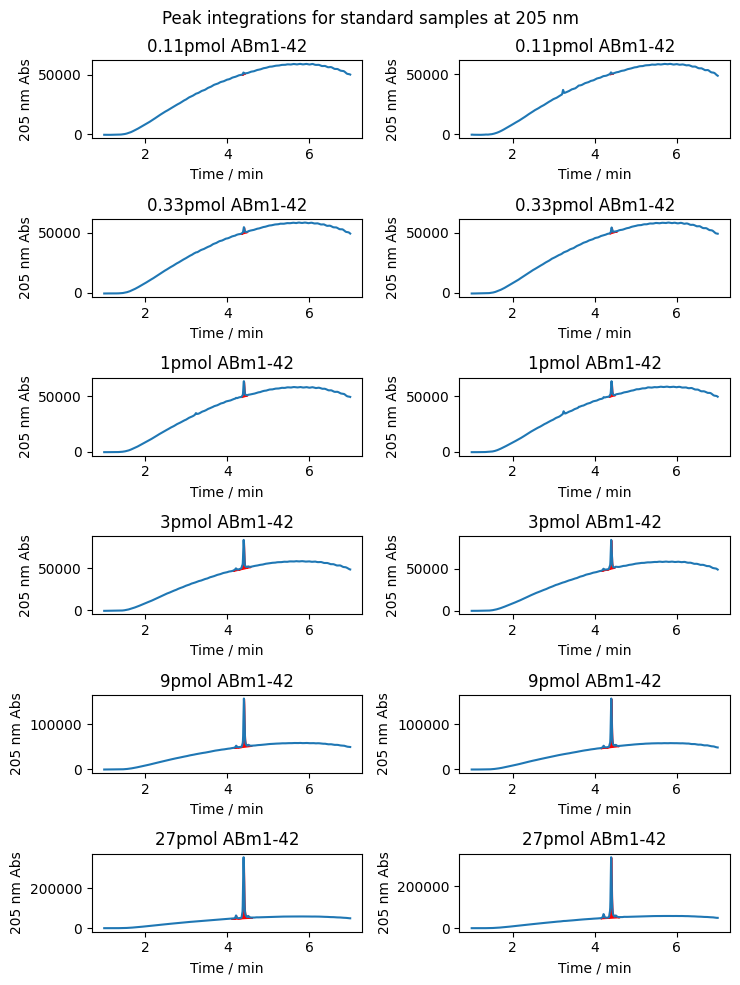

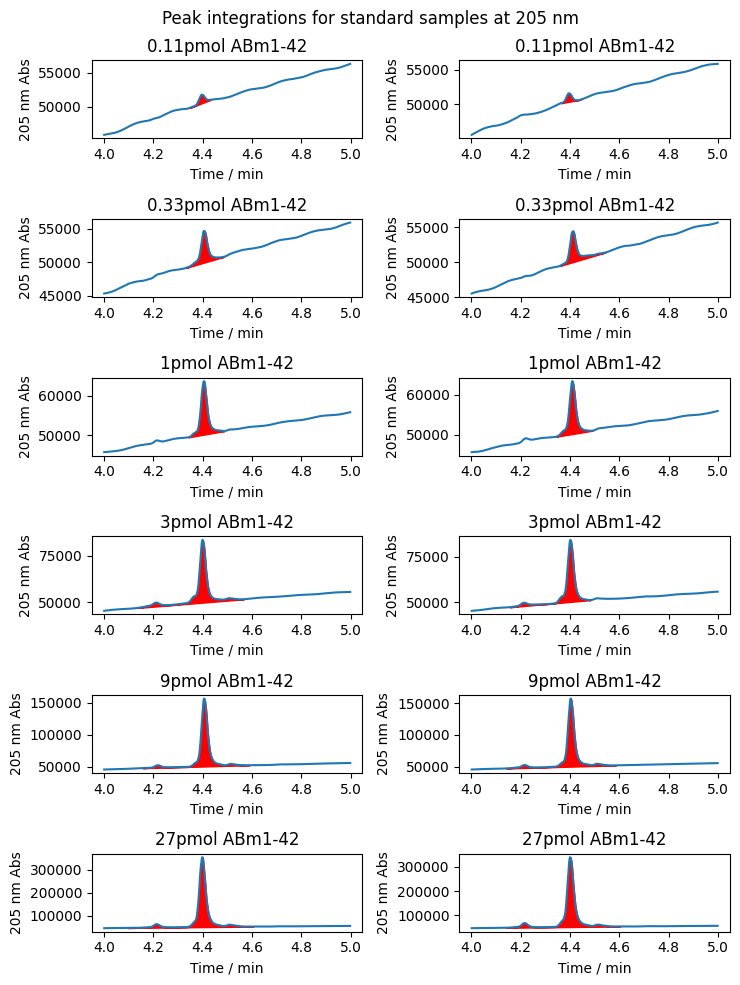

In [26]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for standard samples at 205 nm')
    plt.tight_layout()
    #plt.savefig('plots/260105 seeded temp sol/205nm integrations for samples at'+str(temp)+'degrees-original ints.pdf')

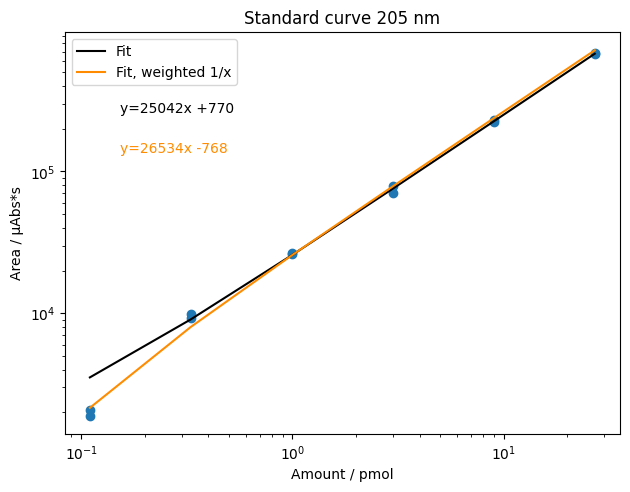

In [27]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x +'+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x '+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / µAbs*s')
plt.tight_layout()
plt.title('Standard curve 205 nm')
std_curve_eq = fit_w

### Controls

In [28]:
UV.filter(pl.col('Data Filename').str.contains('QC')
              ).filter(~pl.col('Vial#').str.contains('-1')
              )

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""A1""","""buffer240510""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_buffer24…","""Control""",null,null,null,null,null,null,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.408,166353.0,6.566,74926.0,4.157,4.647,null
"""B1""","""10uM ABm1-42""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.393,1.70879e6,67.401,712108.0,4.15,4.665,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.41,172731.0,6.818,76782.0,4.102,4.577,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.407,176389.0,6.962,77684.0,4.152,4.638,null


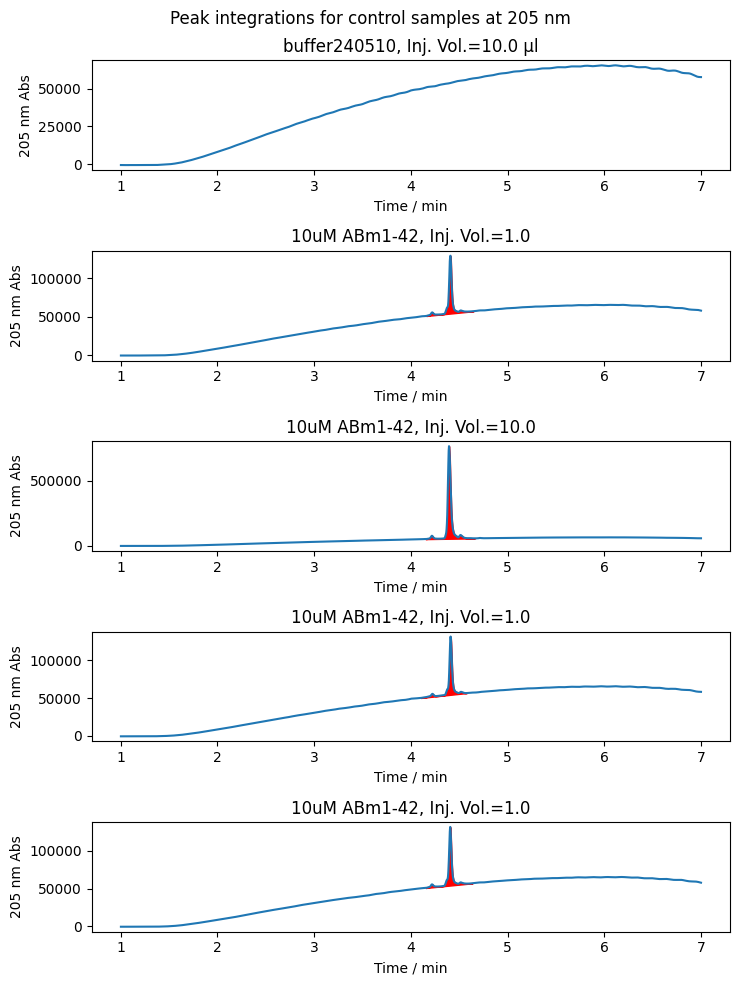

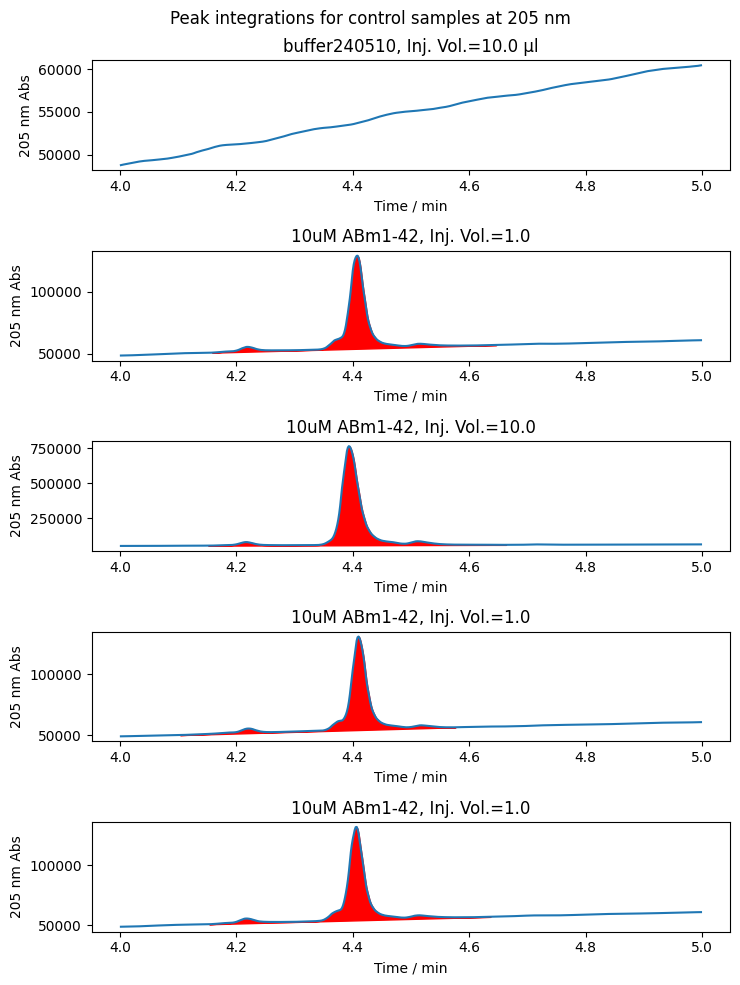

In [29]:

for zoom in [(1,7),(4,5)]:
    control_areas = []
    control_names = []
    control_inj_vols = []
    fig, axs = plt.subplots(5,figsize=(7.5,10),sharey=False)

    for n,name in enumerate(UV.filter(pl.col('Data Filename').str.contains('QC')
                  ).filter(~pl.col('Vial#').str.contains('-1')
                  )['Data Filename']):
        if UV.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[n].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            control_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            control_names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            control_inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])

            axs[n].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0]))
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[n].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])+' µl')
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for control samples at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205 integrations for controls zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')

### Samples

In [30]:
UV.filter(pl.col('Sample Type')=="Unknown"
         ).filter(pl.col('Data Filename').str.contains('65h'))

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""A2""","""10deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_10d…","""Unknown""",4.378,4.080959e6,160.96,1.312528e6,3.988,4.767,null
"""A3""","""10deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_10d…","""Unknown""",4.383,3.966073e6,156.429,1.267703e6,4.072,4.777,null
"""A4""","""10deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_10d…","""Unknown""",4.385,3.923682e6,154.757,1.247758e6,3.938,4.773,null
"""A5""","""10deg-buffer""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_10d…","""Unknown""",null,null,null,null,null,null,null
"""B2""","""18deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_18d…","""Unknown""",4.4,199939.0,7.891,64024.0,4.093,4.673,null
"""B3""","""18deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_18d…","""Unknown""",4.41,169216.0,6.679,55984.0,4.15,4.603,null
"""B4""","""18deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_18d…","""Unknown""",4.41,202991.0,8.012,63169.0,4.142,4.682,null
"""B5""","""18deg-buffer""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_18d…","""Unknown""",null,null,null,null,null,null,null
"""C2""","""23deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_23d…","""Unknown""",4.408,103156.0,4.074,31070.0,4.142,4.595,null


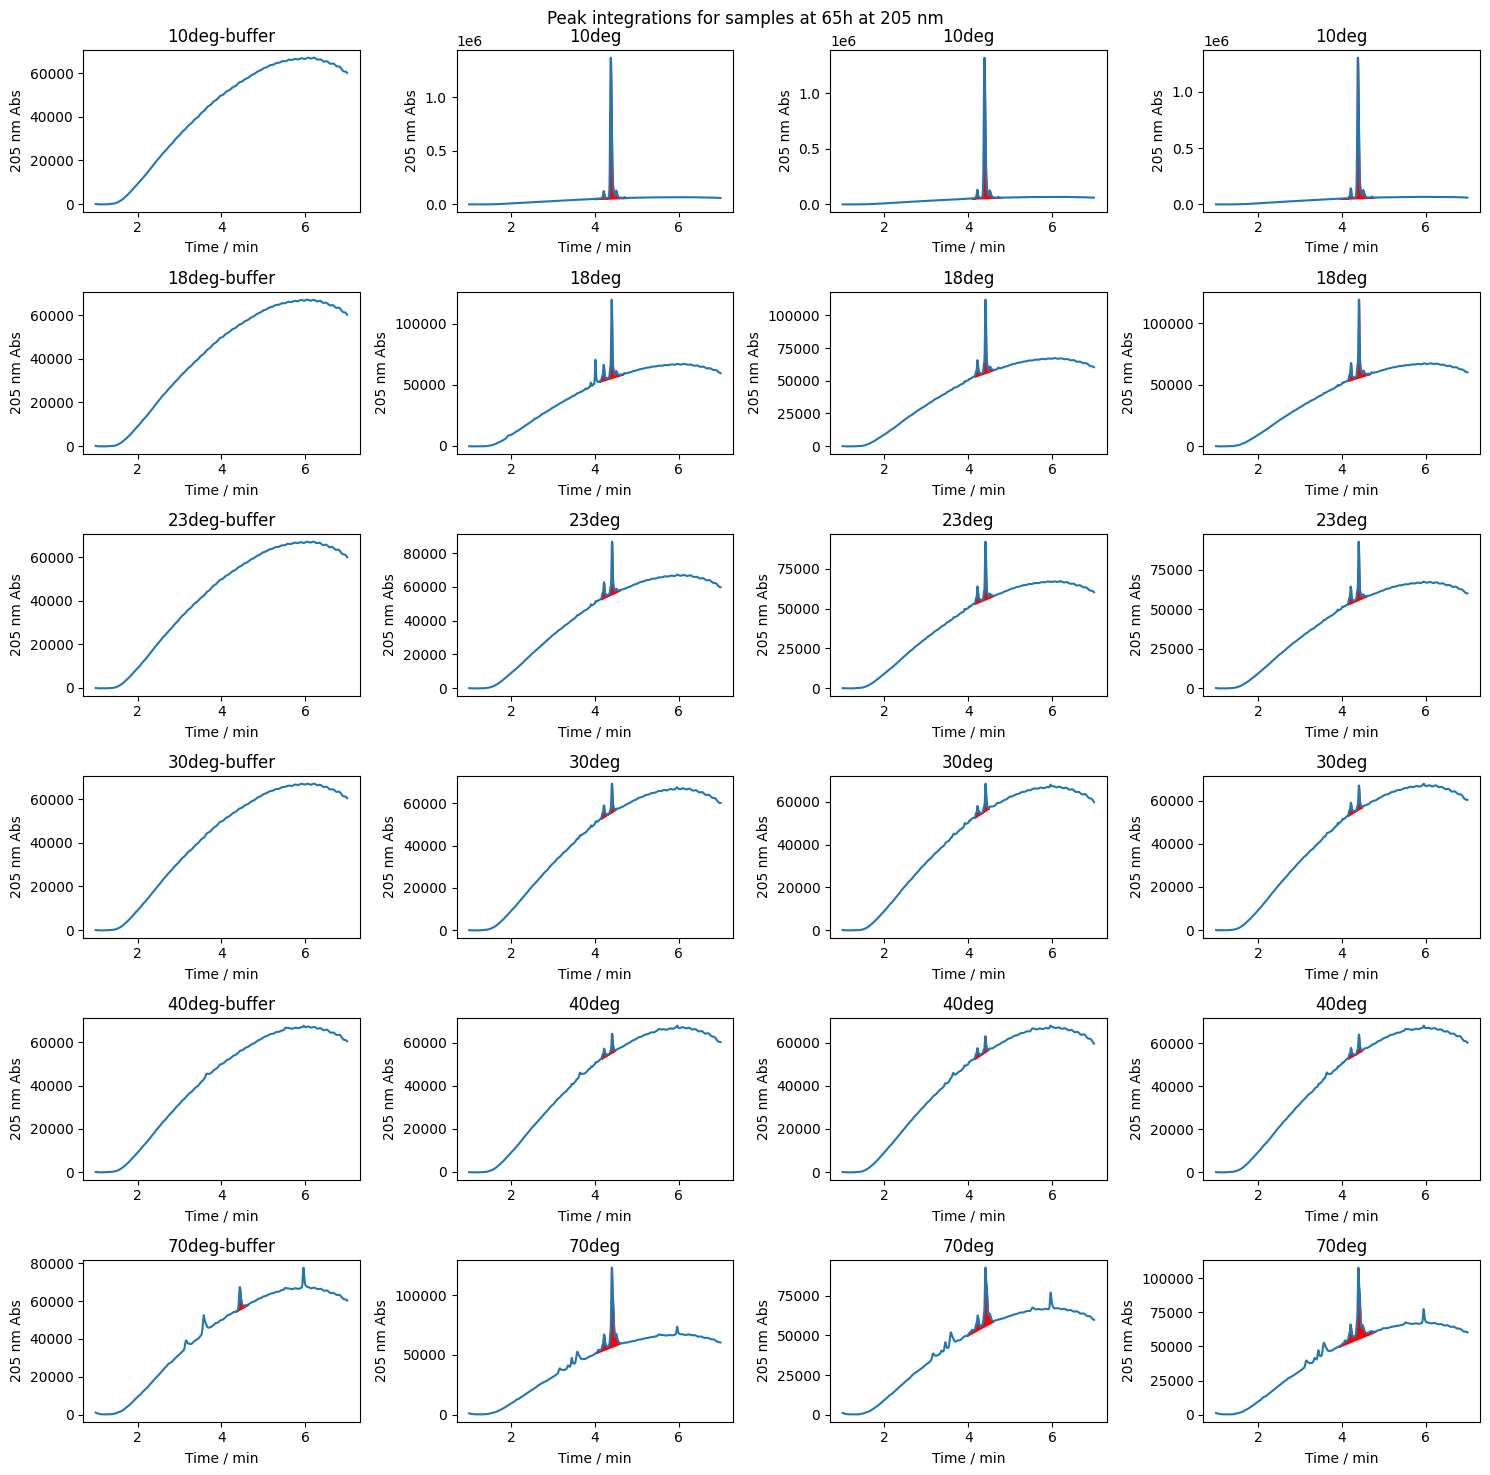

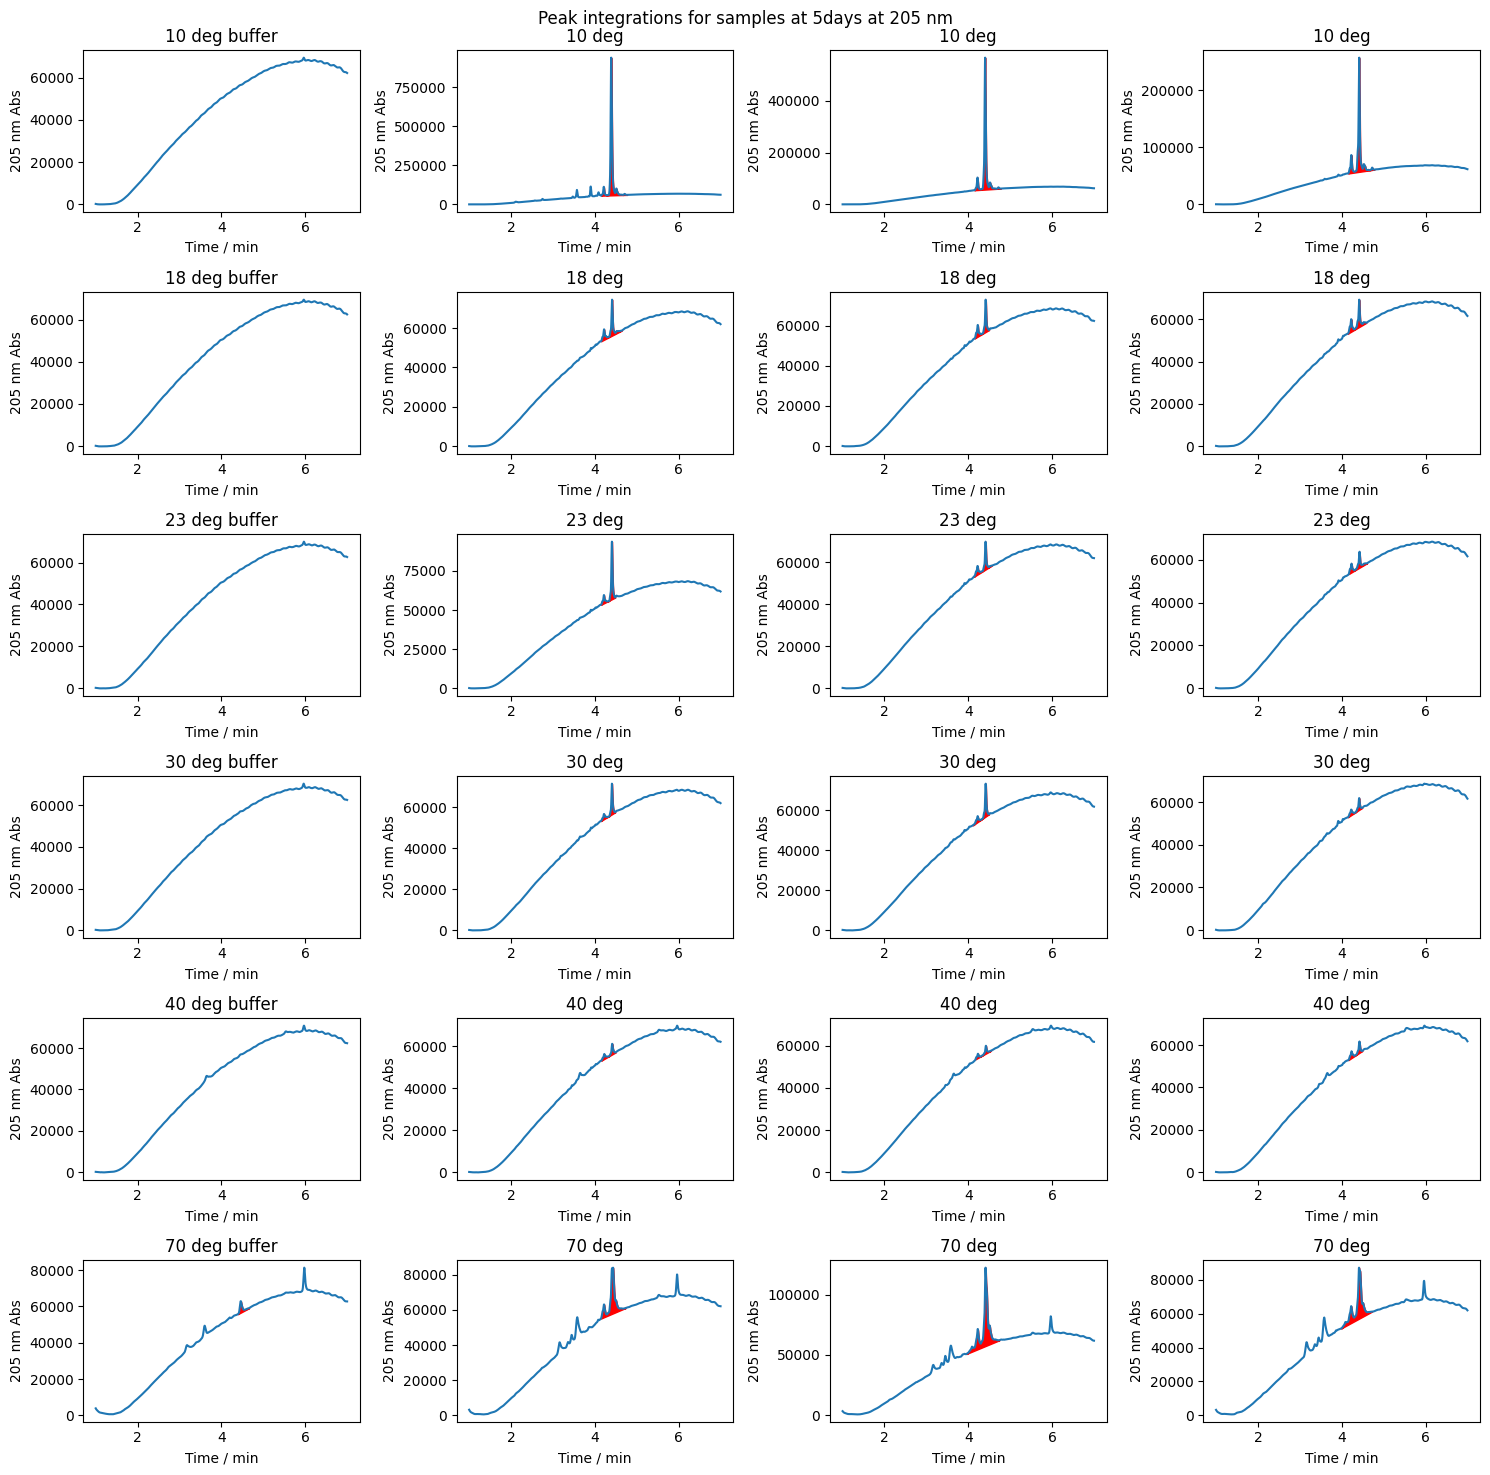

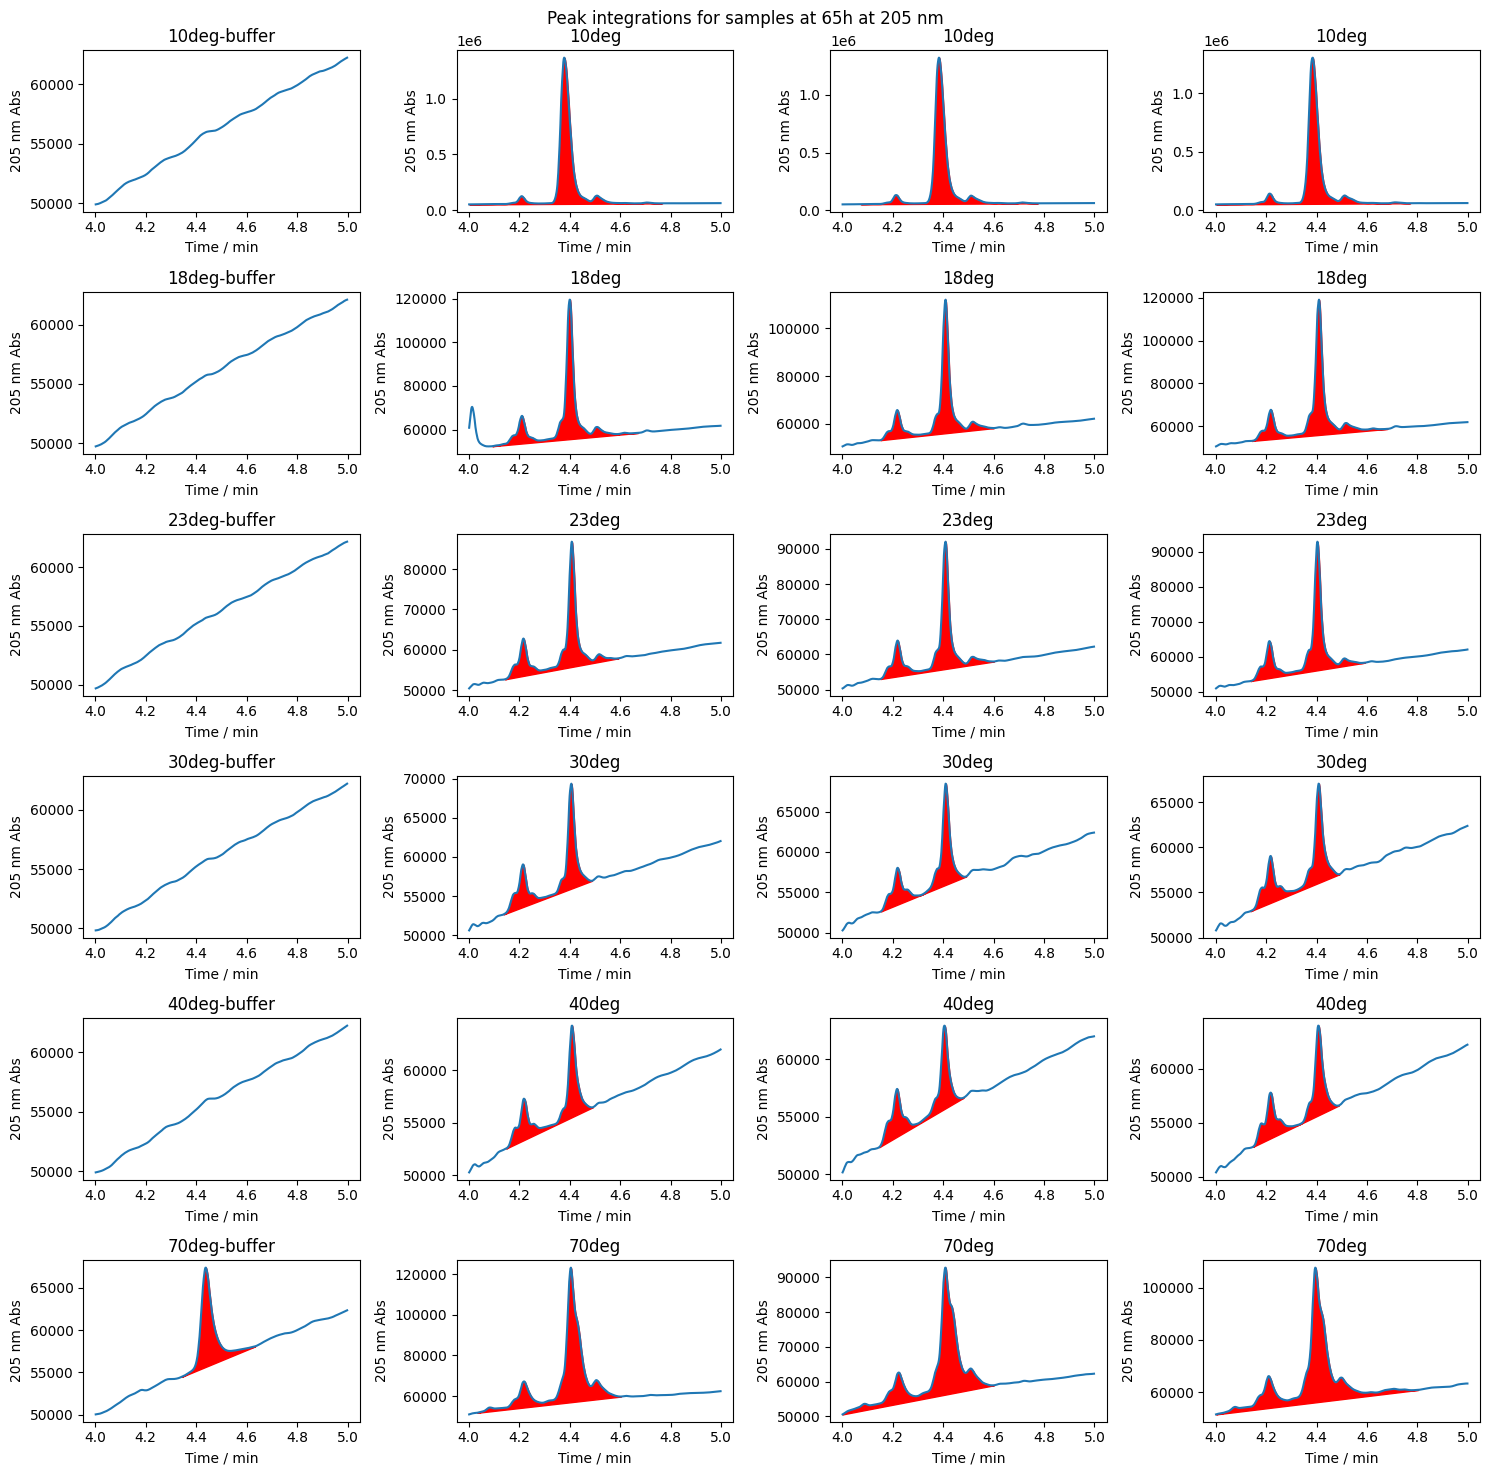

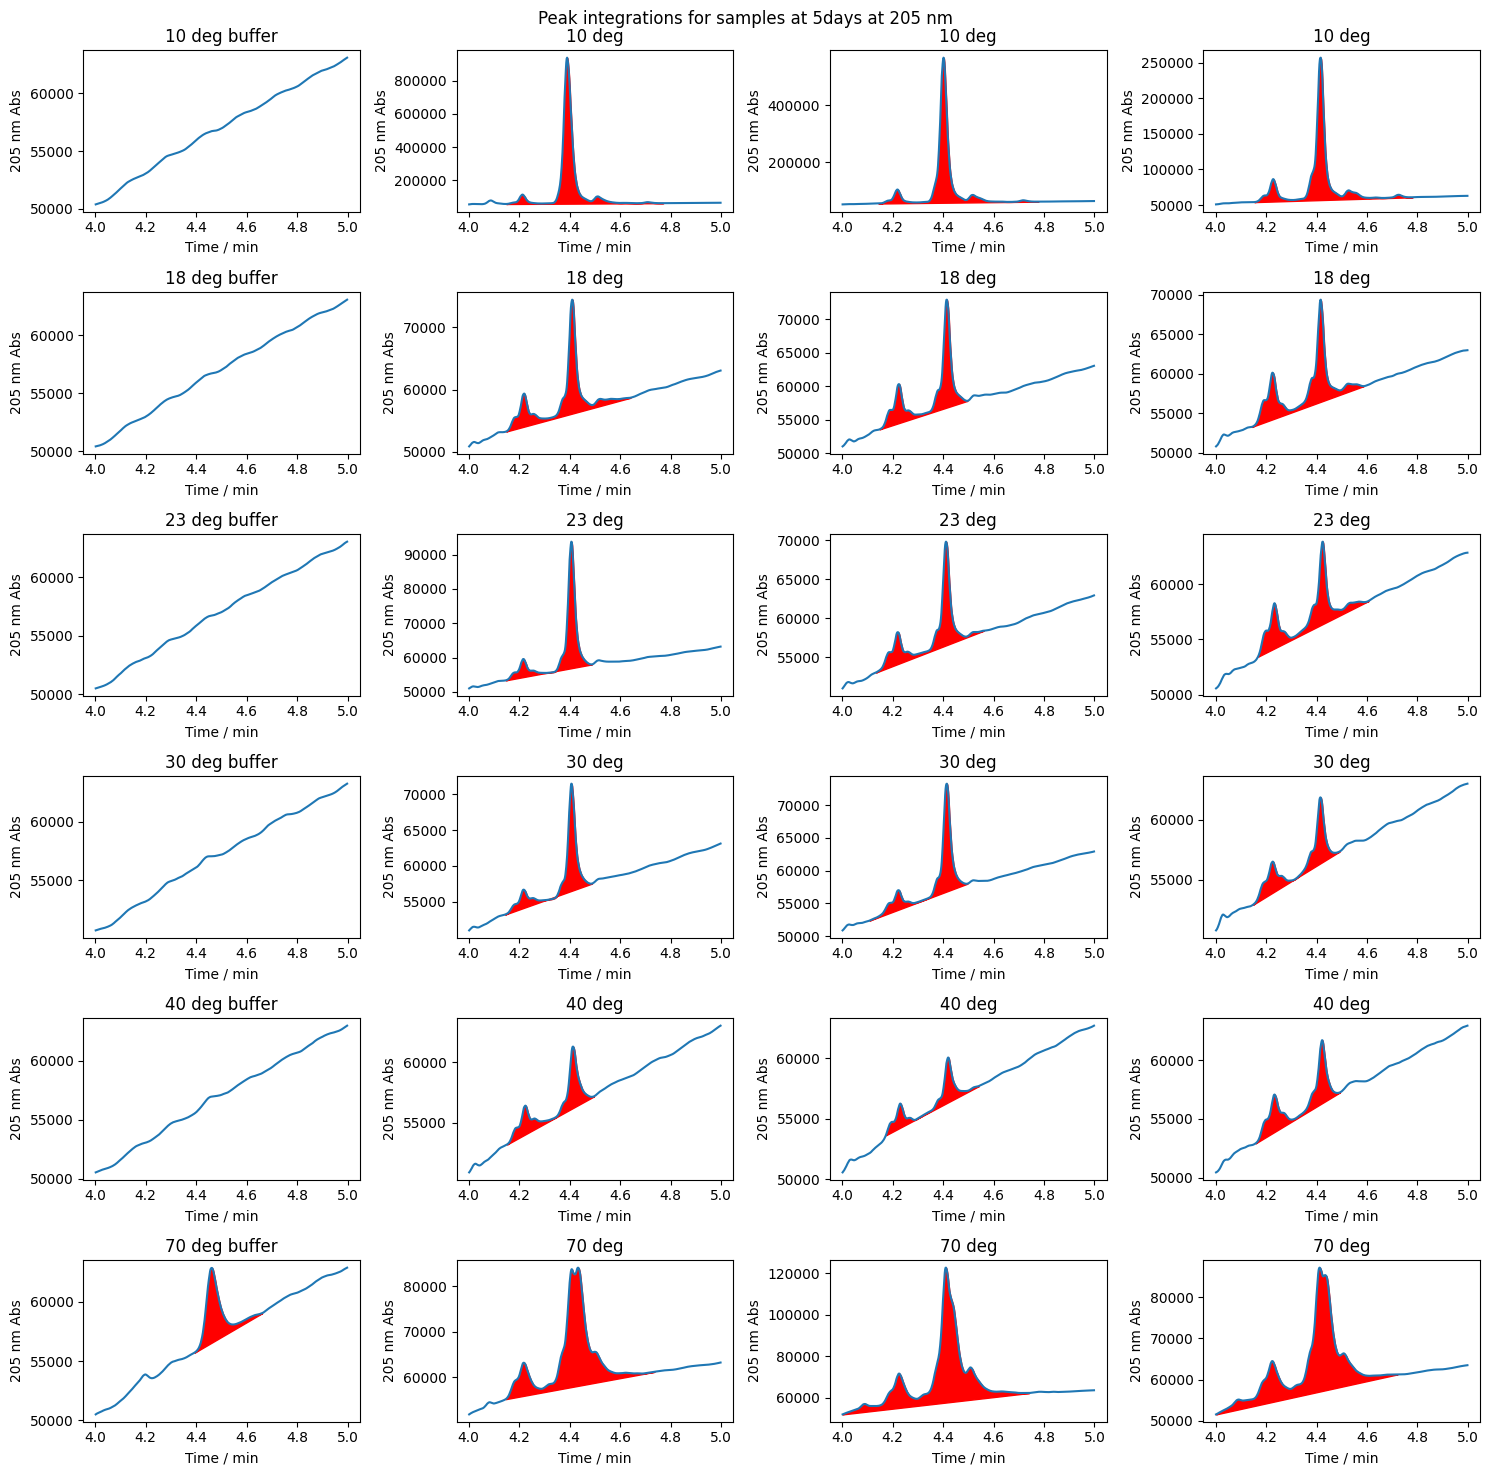

In [31]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
temp_to_row = {'10':0,
               '18':1,
               '23':2,
               '30':3,
               '40':4,
               '70':5}

for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    for time in ['65h','5days']:

        fig, axs = plt.subplots(6,4,figsize=(15,15),sharey=False)
        t_df = UV.filter(pl.col('Sample Type')=="Unknown"
         ).filter(pl.col('Data Filename').str.contains(time))
        
        for n,name in enumerate(t_df['Data Filename']):
            if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
        
                chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
                peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
                peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
                df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                             ).filter(pl.col('Time (min)')<zoom[1])
                x=np.array([df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                       df.filter(pl.col('Time (min)')>peak_start
                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
                y=[df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
                slope, intercept = np.polyfit(x, y, 1)
                baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
                i=temp_to_row[(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][0]+
                   t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][1])]
                if time=='65h':
                    j=[0 if 'buffer' in t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0]
                    else int(t_df.filter(pl.col('Data Filename')==name)['Vial#'][0][-1])-1][0]
                if time=='5days':
                    j=[0 if 'buffer' in t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0]
                    else int(t_df.filter(pl.col('Data Filename')==name)['Vial#'][0][1:])-7][0]
                axs[i,j].plot(df['Time (min)'],
                         df['Abs (µAu)'])
                poly_collect = axs[i,j].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                                 df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                                baseline,color='red')
                paths = poly_collect.get_paths()
                area = 0
                for path in paths:
                    poly = Polygon(path.vertices)
                    area += poly.area
                areas.append(area*60) # to get it in µAbs*s as in Labsolutions
                names.append(time+' '+UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
                axs[i,j].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                axs[i,j].set_xlabel('Time / min')
                axs[i,j].set_ylabel('205 nm Abs')
            else:
                chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
                df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                             ).filter(pl.col('Time (min)')<zoom[1])
                i=temp_to_row[(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][0]+
                   t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][1])]
                if time=='65h':
                    j=[0 if 'buffer' in t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0]
                    else int(t_df.filter(pl.col('Data Filename')==name)['Vial#'][0][-1])-1][0]
                if time=='5days':
                    j=[0 if 'buffer' in t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0]
                    else int(t_df.filter(pl.col('Data Filename')==name)['Vial#'][0][1:])-7][0]
                axs[i,j].plot(df['Time (min)'],
                         df['Abs (µAu)'])
                axs[i,j].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                axs[i,j].set_xlabel('Time / min')
                axs[i,j].set_ylabel('205 nm Abs')
        plt.suptitle('Peak integrations for samples at '+time+' at 205 nm')
        plt.tight_layout()
        plt.savefig('plots/'+project_name+'/205nm integrations for samples at '+time+' at 205 nm-zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')
    

### Calc. Conc.

In [32]:
amounts_UV= pl.DataFrame({'Sample Name':names+control_names,
                           'Area (python)':areas+control_areas,
                          'Inj. Vol.':inj_vols+control_inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_UV_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [33]:
amounts_UV

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""65h 10deg""",4.0647e6,30.0,153.214485
"""65h 10deg""",3.9406e6,30.0,148.537376
"""65h 10deg""",3.9061e6,30.0,147.238953
"""65h 18deg""",194965.06425,30.0,7.376642
"""65h 18deg""",168825.67044,30.0,6.391522
"""65h 18deg""",203006.89638,30.0,7.679717
"""65h 23deg""",103047.51129,30.0,3.912527
"""65h 23deg""",120527.90163,30.0,4.571314
"""65h 23deg""",122206.579398,30.0,4.634578


In [34]:
concs_UV=amounts_UV.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_UV.filter(pl.col('Sample Name').str.contains('40')
                                )

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""65h 40deg""",33829.689612,30.0,1.3039,43.463338
"""65h 40deg""",31363.064685,30.0,1.21094,40.364665
"""65h 40deg""",35113.777032,30.0,1.352294,45.076461
"""5days 40 deg""",25888.721847,30.0,1.004627,33.487575
"""5days 40 deg""",22032.986538,30.0,0.859315,28.643845
"""5days 40 deg""",15479.583333,30.0,0.612336,20.411196


In [35]:
corr_factor = (10000/
concs_UV.filter(pl.col('Sample Name')=="10uM ABm1-42"
                )['Conc. (nM)'][0])
corr_factor

1.5240898866153074

In [36]:
concs_UV=concs_UV.with_columns(
    (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
)

In [37]:
concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                        ).filter(pl.col('Sample Name').str.contains('70')
                            ).filter(pl.col('Sample Name').str.contains('65h'))['Corr. Conc. (nM)'].to_numpy()

array([593.21768736, 391.63142537, 570.97206034])

In [38]:
concs_UV.filter(pl.col('Sample Name').str.contains('buffer'))
                                    

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM),Corr. Conc. (nM)
str,f64,f64,f64,f64,f64
"""65h 70deg-buffer""",40614.846765,30.0,1.559614,51.987126,79.233053
"""5days 70 deg buffer""",24497.312409,30.0,0.952189,31.73963,48.37405


In [39]:
temp=18
y_t1=(concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('buffer')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if temp==70
 else 0
             ][0])
y_t1=y_t1.filter(y_t1>0).to_numpy()
y_t1

array([374.75553824, 324.70845211, 390.15261547])

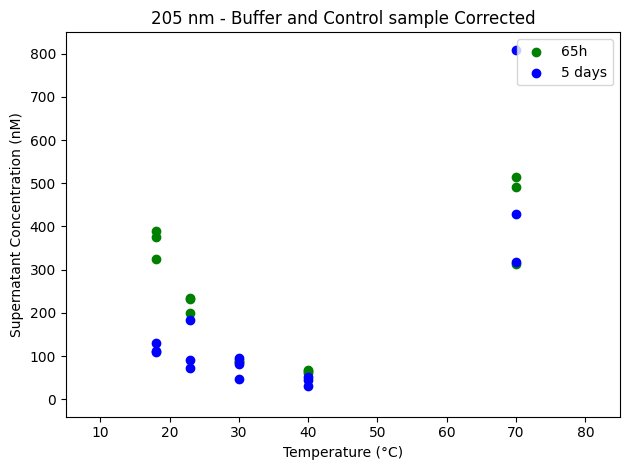

In [40]:
temps=[18,23,30,40,70]
buffer_corr_t1=[]
buffer_corr_t2=[]
temps_t1=[]
temps_t2=[]
for temp in temps:
    y_t1=(concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('buffer')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if temp==70
 else 0
             ][0])#gather all 65h values for a certain temperature except buffer
                  #then subtract the buffer value from all of them
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    buffer_corr_t1.append(y_t1)
    temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([int(temp)]*len(y_t1),y_t1,color='green')
    
    y_t2=(concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('5days')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('buffer')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('5days')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if temp==70
 else 0
             ][0])#gather all 5 days values for a certain temperature except buffer
                  #then subtract the buffer value from all of them
    y_t2=y_t2.filter(y_t2>0).to_numpy()
    buffer_corr_t2.append(y_t2)
    temps_t2.append([int(temp)]*len(y_t2))
    
    plt.scatter([int(temp)]*len(y_t2),y_t2,color='blue')

buffer_corr_values = pl.DataFrame({'Temp':temps_t1+temps_t2,
                                           'Conc (nM)':buffer_corr_t1+buffer_corr_t2,
                                           'Incubation time (days)':[2.7]*len(temps_t1)+[5]*len(temps_t2)
                                          })
plt.scatter(0,0,color='green',label='65h')
plt.scatter(0,0,color='blue',label='5 days')
plt.xlim(5,85)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - Buffer and Control sample Corrected')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates-corr by control sample-buffer corr.pdf')

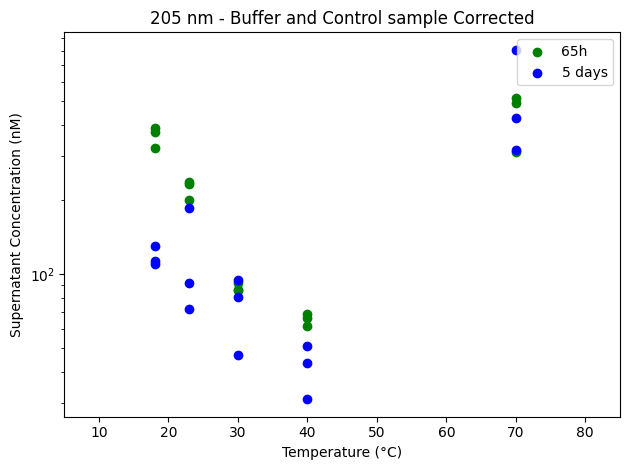

In [41]:
temps=[18,23,30,40,70]
buffer_corr_t1=[]
buffer_corr_t2=[]
temps_t1=[]
temps_t2=[]
for temp in temps:
    y_t1=(concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('buffer')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if temp==70
 else 0
             ][0])#gather all 65h values for a certain temperature except buffer
                  #then subtract the buffer value from all of them
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    buffer_corr_t1.append(y_t1)
    temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([int(temp)]*len(y_t1),y_t1,color='green')
    
    y_t2=(concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('5days')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            -[concs_UV.filter(pl.col('Sample Name').str.contains('buffer')
                                    ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('5days')
                                        )['Corr. Conc. (nM)'].to_numpy()[0]
 if temp==70
 else 0
             ][0])#gather all 5 days values for a certain temperature except buffer
                  #then subtract the buffer value from all of them
    y_t2=y_t2.filter(y_t2>0).to_numpy()
    buffer_corr_t2.append(y_t2)
    temps_t2.append([int(temp)]*len(y_t2))
    
    plt.scatter([int(temp)]*len(y_t2),y_t2,color='blue')

buffer_corr_values = pl.DataFrame({'Temp':temps_t1+temps_t2,
                                           'Conc (nM)':buffer_corr_t1+buffer_corr_t2,
                                           'Incubation time (days)':[2.7]*len(temps_t1)+[5]*len(temps_t2)
                                          })
plt.scatter(0,0,color='green',label='65h')
plt.scatter(0,0,color='blue',label='5 days')
plt.xlim(5,85)
plt.semilogy()
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - Buffer and Control sample Corrected')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates-corr by control sample-buffer corr-log.pdf')

In [42]:
buffer_corr_values_eq = buffer_corr_values.explode(['Temp','Conc (nM)']
          ).filter(~((pl.col('Temp')<30) & (pl.col('Incubation time (days)')<3))
                  ) # remove the early timepoint of the two lowest temperatures, as they don't seem to have reached equilibrium
buffer_corr_values_eq

Temp,Conc (nM),Incubation time (days)
i64,f64,f64
30,91.545634,2.7
30,86.261663,2.7
30,86.519304,2.7
40,66.242034,2.7
40,61.519377,2.7
40,68.700578,2.7
70,513.984635,2.7
70,312.398373,2.7
70,491.739008,2.7


In [43]:
buffer_corr_values_eq.write_csv('Processed data/'+project_name+'/buffer-corrected values 260115.csv')

## MS

### Standard curve

In [44]:
stds = MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.411,7114.0,0.068,1993.0,4.35,4.567,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.423,21860.0,0.366,6440.0,4.35,4.567,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.426,21744.0,0.364,6361.0,4.333,4.567,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.42,66732.0,1.274,19359.0,4.35,4.6,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.426,60146.0,1.141,16968.0,4.35,4.6,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.416,1.308549e6,26.4,369996.0,4.283,4.6,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.417,1.288584e6,25.996,378560.0,4.35,4.6,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""",4.418,154879.0,3.057,44843.0,4.35,4.6,3.0


In [45]:
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str
1,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.411,7114.0,0.068,1993.0,0.11,61.4,"""*""",4.35,4.567,0.49,1.38,"""1.603"""
2,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.413,7391.0,0.073,2228.0,0.11,66.5,"""*""",4.35,4.517,0.43,1.7,"""1.458"""
3,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.426,21744.0,0.364,6361.0,0.33,110.2,"""*""",4.333,4.567,0.96,3.8,"""1.373"""
4,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.423,21860.0,0.366,6440.0,0.33,110.9,"""*""",4.35,4.567,1.0,3.67,"""1.405"""
5,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.426,60146.0,1.141,16968.0,1.0,114.1,"""*""",4.35,4.6,1.31,8.72,"""1.506"""
6,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.42,66732.0,1.274,19359.0,1.0,127.4,"""*""",4.35,4.6,1.43,8.93,"""1.342"""
7,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.419,154087.0,3.041,44683.0,3.0,101.4,"""*""",4.35,4.6,0.67,45.17,"""1.451"""
8,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.418,154879.0,3.057,44843.0,3.0,101.9,"""*""",4.35,4.6,0.65,47.16,"""1.470"""
9,"""240428-std curve_9pmol ABm1-42…","""Standard(Calc.Point)""","""9pmol ABm1-42""","""C2""",4.419,467398.0,9.381,134304.0,9.0,104.2,"""*""",4.333,4.6,0.96,97.53,"""1.441"""


In [46]:
data_MS['240428-std curve_27pmol ABm1-42_001_13.txt_MS-TIC']

Time (min),Absolute Intensity,Relative Intensity
f64,i64,f64
0.5,4331,1.15
0.517,4415,1.18
0.533,4437,1.18
0.55,4411,1.18
0.567,4409,1.18
0.583,4453,1.19
0.6,4596,1.23
0.617,4769,1.27
0.633,4744,1.27


In [47]:
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_none_001…","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_none_001…","""Control""",4.421,2377.0,-0.028,693.0,4.367,4.483,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_non…","""Control""",4.624,1179.0,-0.053,338.0,4.583,4.683,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_non…","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t2(5days)_n…","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t2(5days)_n…","""Control""",4.332,984.0,-0.056,362.0,4.3,4.4,null
"""A1""","""buffer240510""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_buffer24…","""Control""",4.267,2496.0,-0.026,169.0,null,null,null


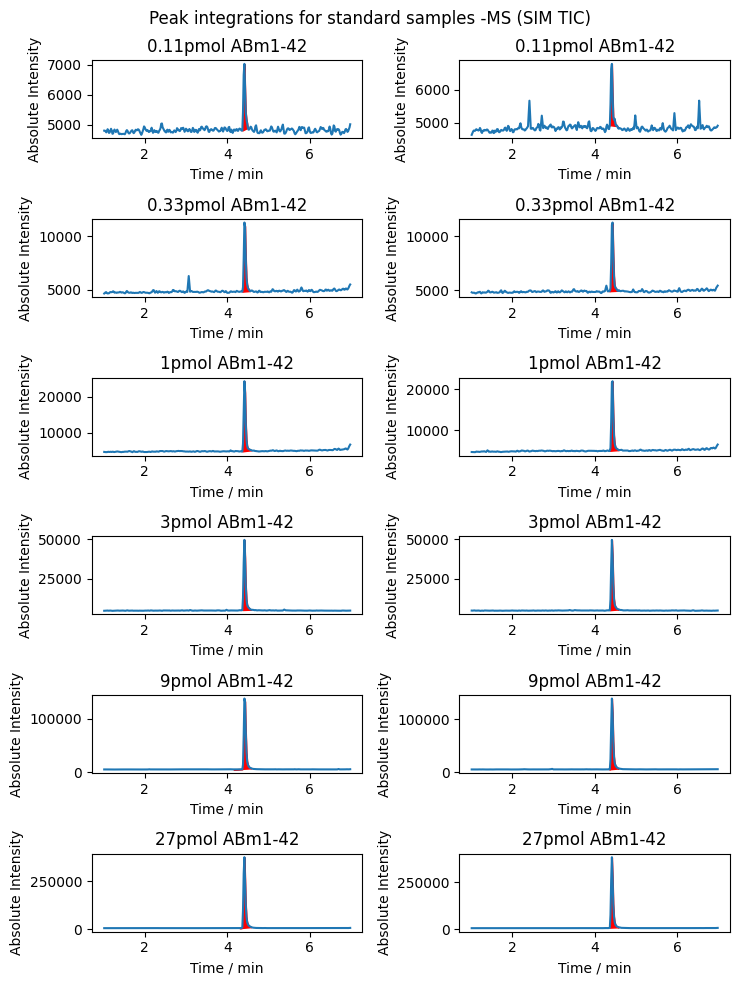

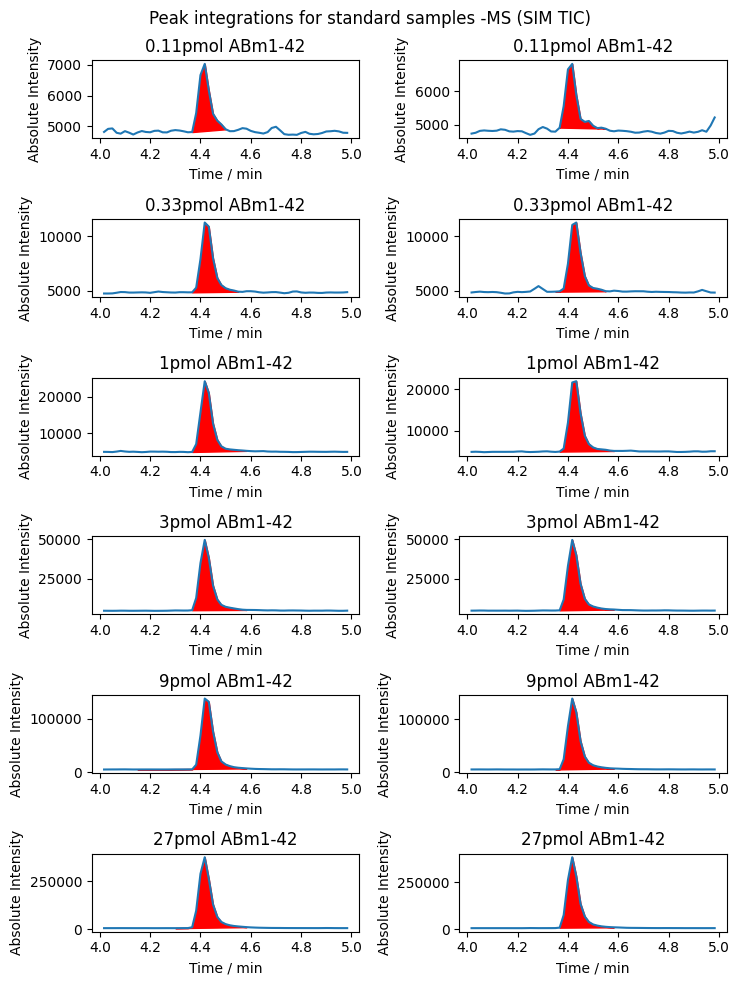

In [48]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in A.U.*s as in Labsolutions?
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for standard samples -MS (SIM TIC)')
    plt.tight_layout()
    #plt.savefig('plots/260105 seeded temp sol/205nm integrations for samples at'+str(temp)+'degrees-original ints.pdf')

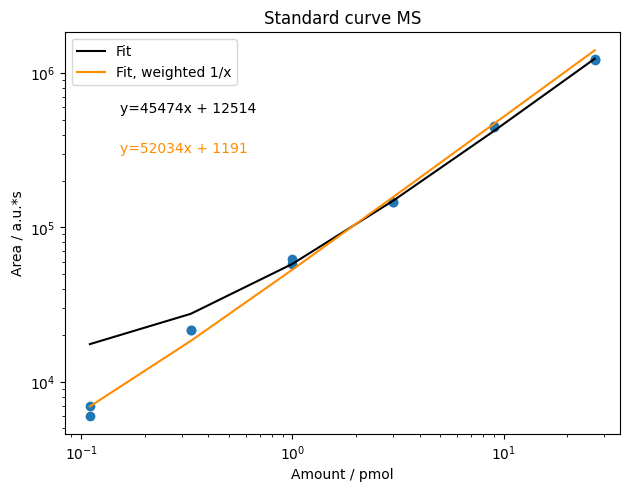

In [49]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x + '+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x + '+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / a.u.*s')
plt.tight_layout()
plt.title('Standard curve MS')
std_curve_eq = fit_w

### Controls

In [50]:
MS.filter(pl.col('Data Filename').str.contains('QC')
              ).filter(~pl.col('Vial#').str.contains('-1')
              )

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""A1""","""buffer240510""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_buffer24…","""Control""",4.267,2496.0,-0.026,169.0,null,null,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.422,539643.0,10.842,153770.0,4.35,4.7,null
"""B1""","""10uM ABm1-42""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.412,4.274378e6,86.408,1.127506e6,4.333,4.667,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.425,511062.0,10.264,141537.0,4.35,4.7,null
"""B1""","""10uM ABm1-42""",1.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol QC_10uM ABm…","""Unknown""",4.421,478348.0,9.602,135176.0,4.35,4.7,null


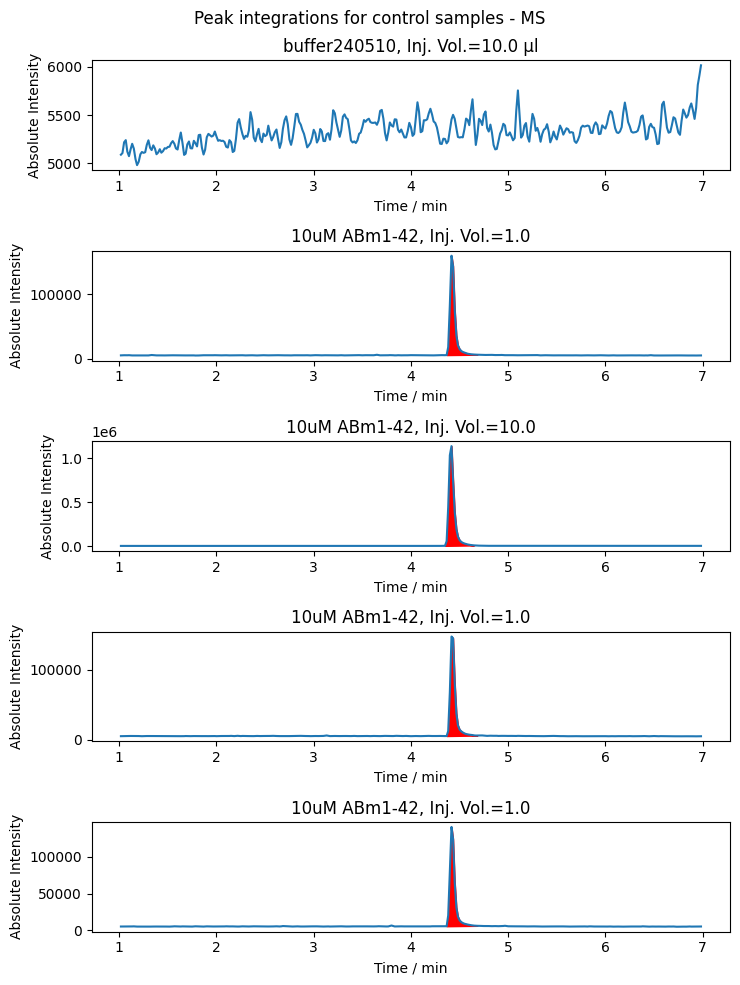

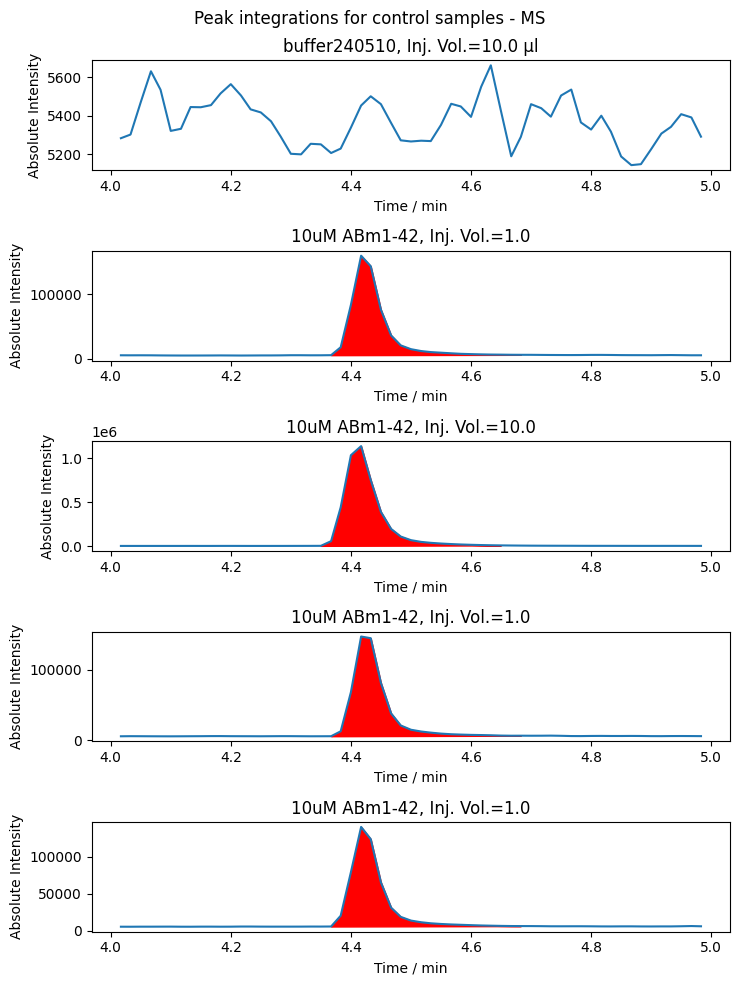

In [51]:

for zoom in [(1,7),(4,5)]:
    control_areas = []
    control_names = []
    control_inj_vols = []
    fig, axs = plt.subplots(5,figsize=(7.5,10),sharey=False)

    for n,name in enumerate(MS.filter(pl.col('Data Filename').str.contains('QC')
                  ).filter(~pl.col('Vial#').str.contains('-1')
                  )['Data Filename']):
        if MS.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(MS.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(MS.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[n].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            control_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            control_names.append(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            control_inj_vols.append(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])

            axs[n].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0]))
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[n].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])+' µl')
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for control samples - MS')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/MS integrations for controls zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')

### Samples

In [52]:
MS.filter(pl.col('Sample Type')=="Unknown"
         ).filter(pl.col('Data Filename').str.contains('65h'))

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""A2""","""10deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_10d…","""Unknown""",4.397,8.878004e6,179.554,2.199219e6,4.317,4.65,null
"""A3""","""10deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_10d…","""Unknown""",4.402,7.460227e6,150.867,1.928409e6,4.317,4.667,null
"""A4""","""10deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_10d…","""Unknown""",4.402,7.05273e6,142.623,1.800242e6,4.317,4.667,null
"""A5""","""10deg-buffer""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_10d…","""Unknown""",4.367,1451.0,-0.047,194.0,null,4.567,null
"""B2""","""18deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_18d…","""Unknown""",4.417,371351.0,7.437,109840.0,4.267,4.7,null
"""B3""","""18deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_18d…","""Unknown""",4.426,275557.0,5.499,77103.0,4.27,4.7,null
"""B4""","""18deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_18d…","""Unknown""",4.427,323655.0,6.472,91133.0,4.283,4.667,null
"""B5""","""18deg-buffer""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_18d…","""Unknown""",null,null,null,null,null,null,null
"""C2""","""23deg""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240510 WideTempSol t1(65h)_23d…","""Unknown""",4.425,166039.0,3.283,44992.0,4.317,4.7,null


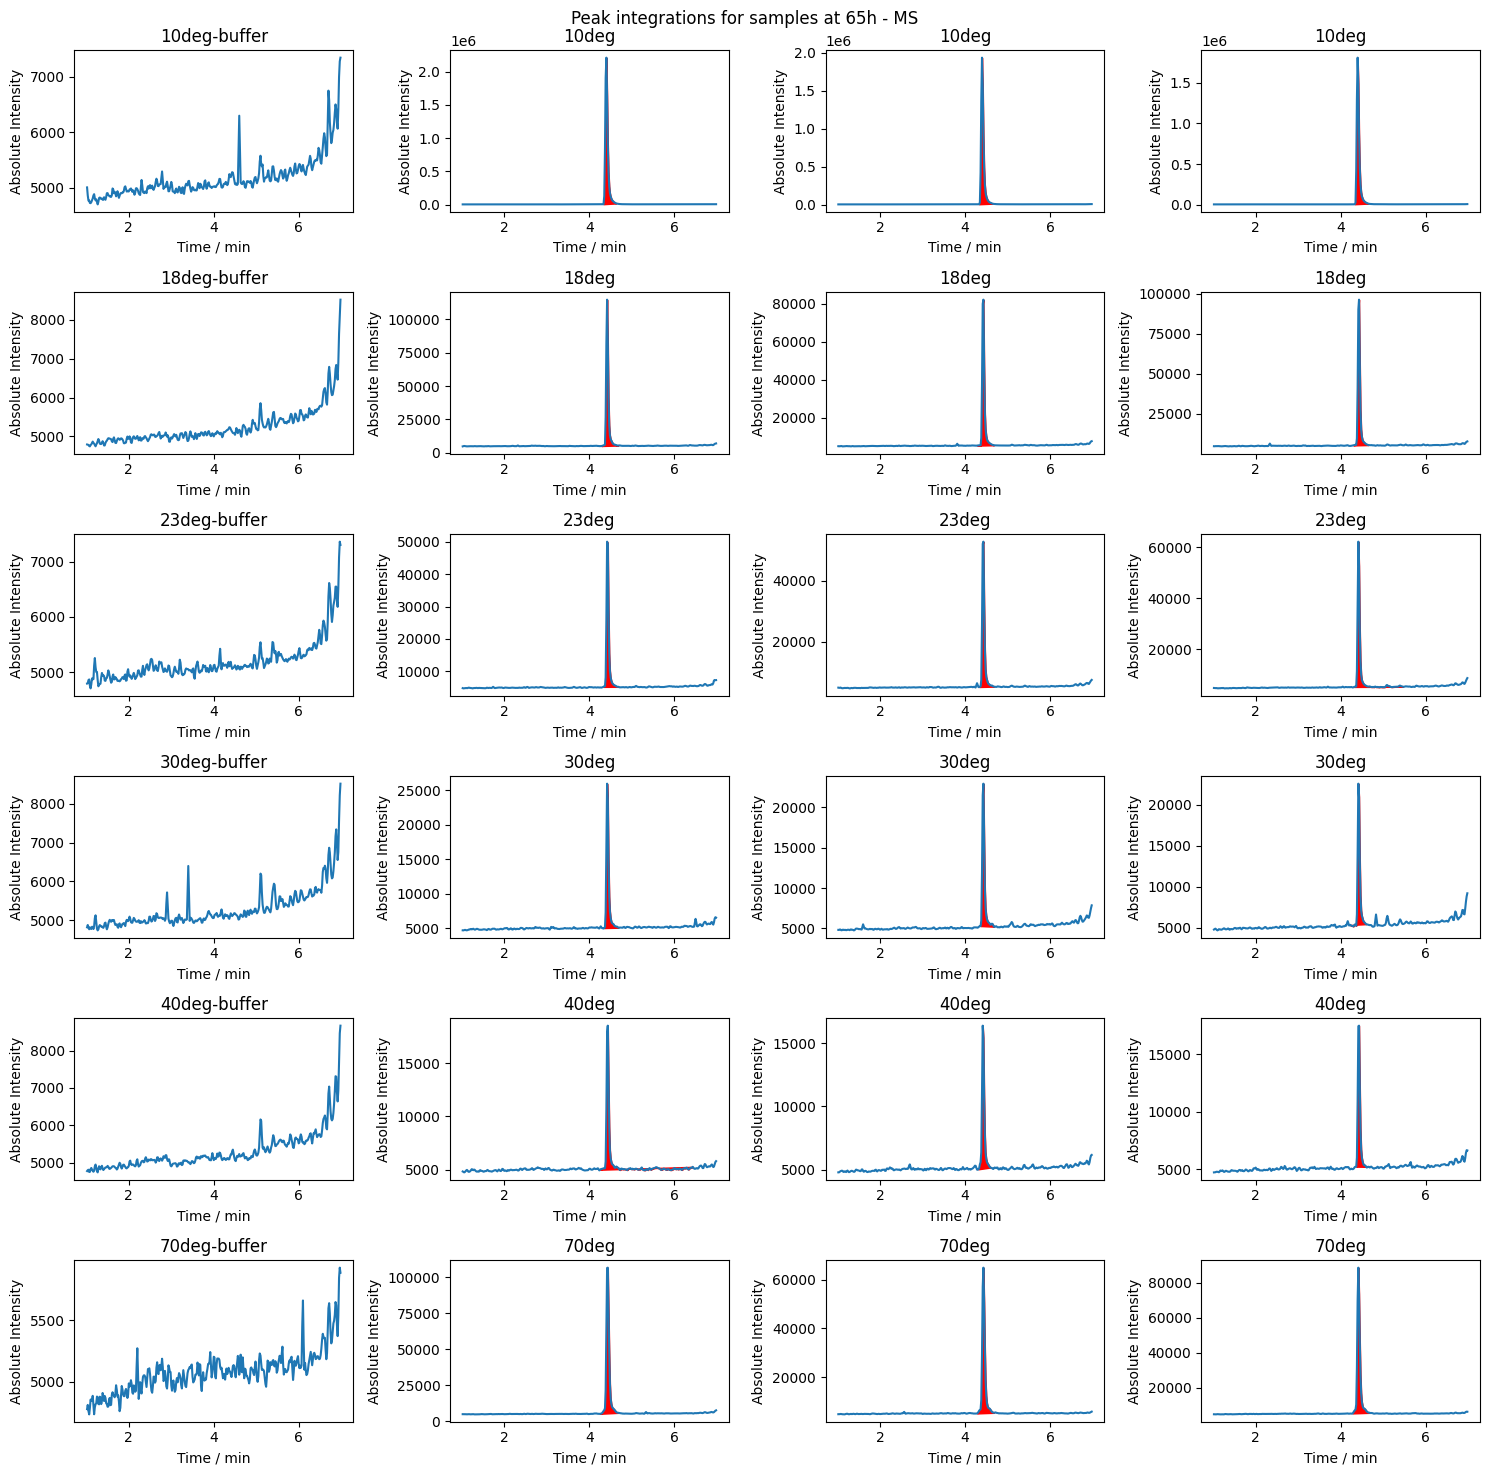

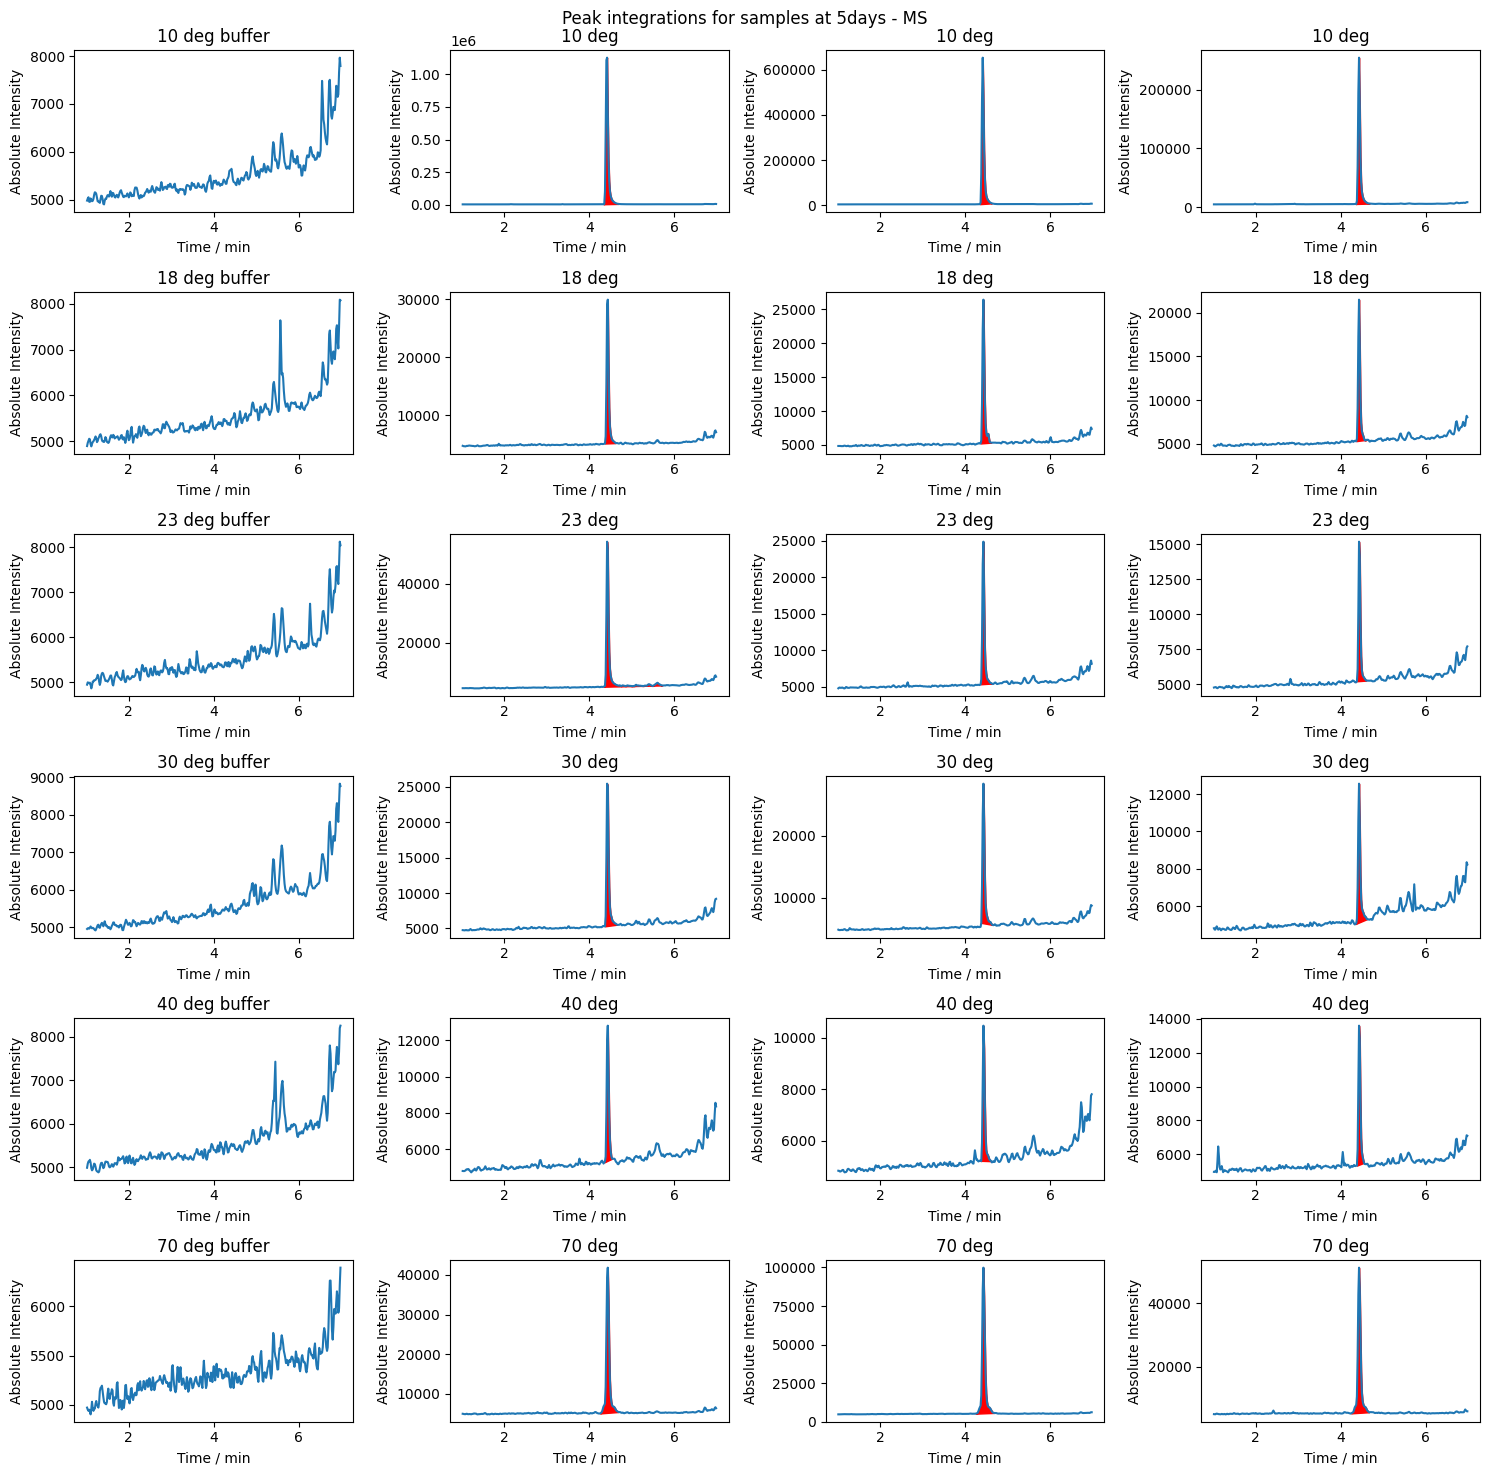

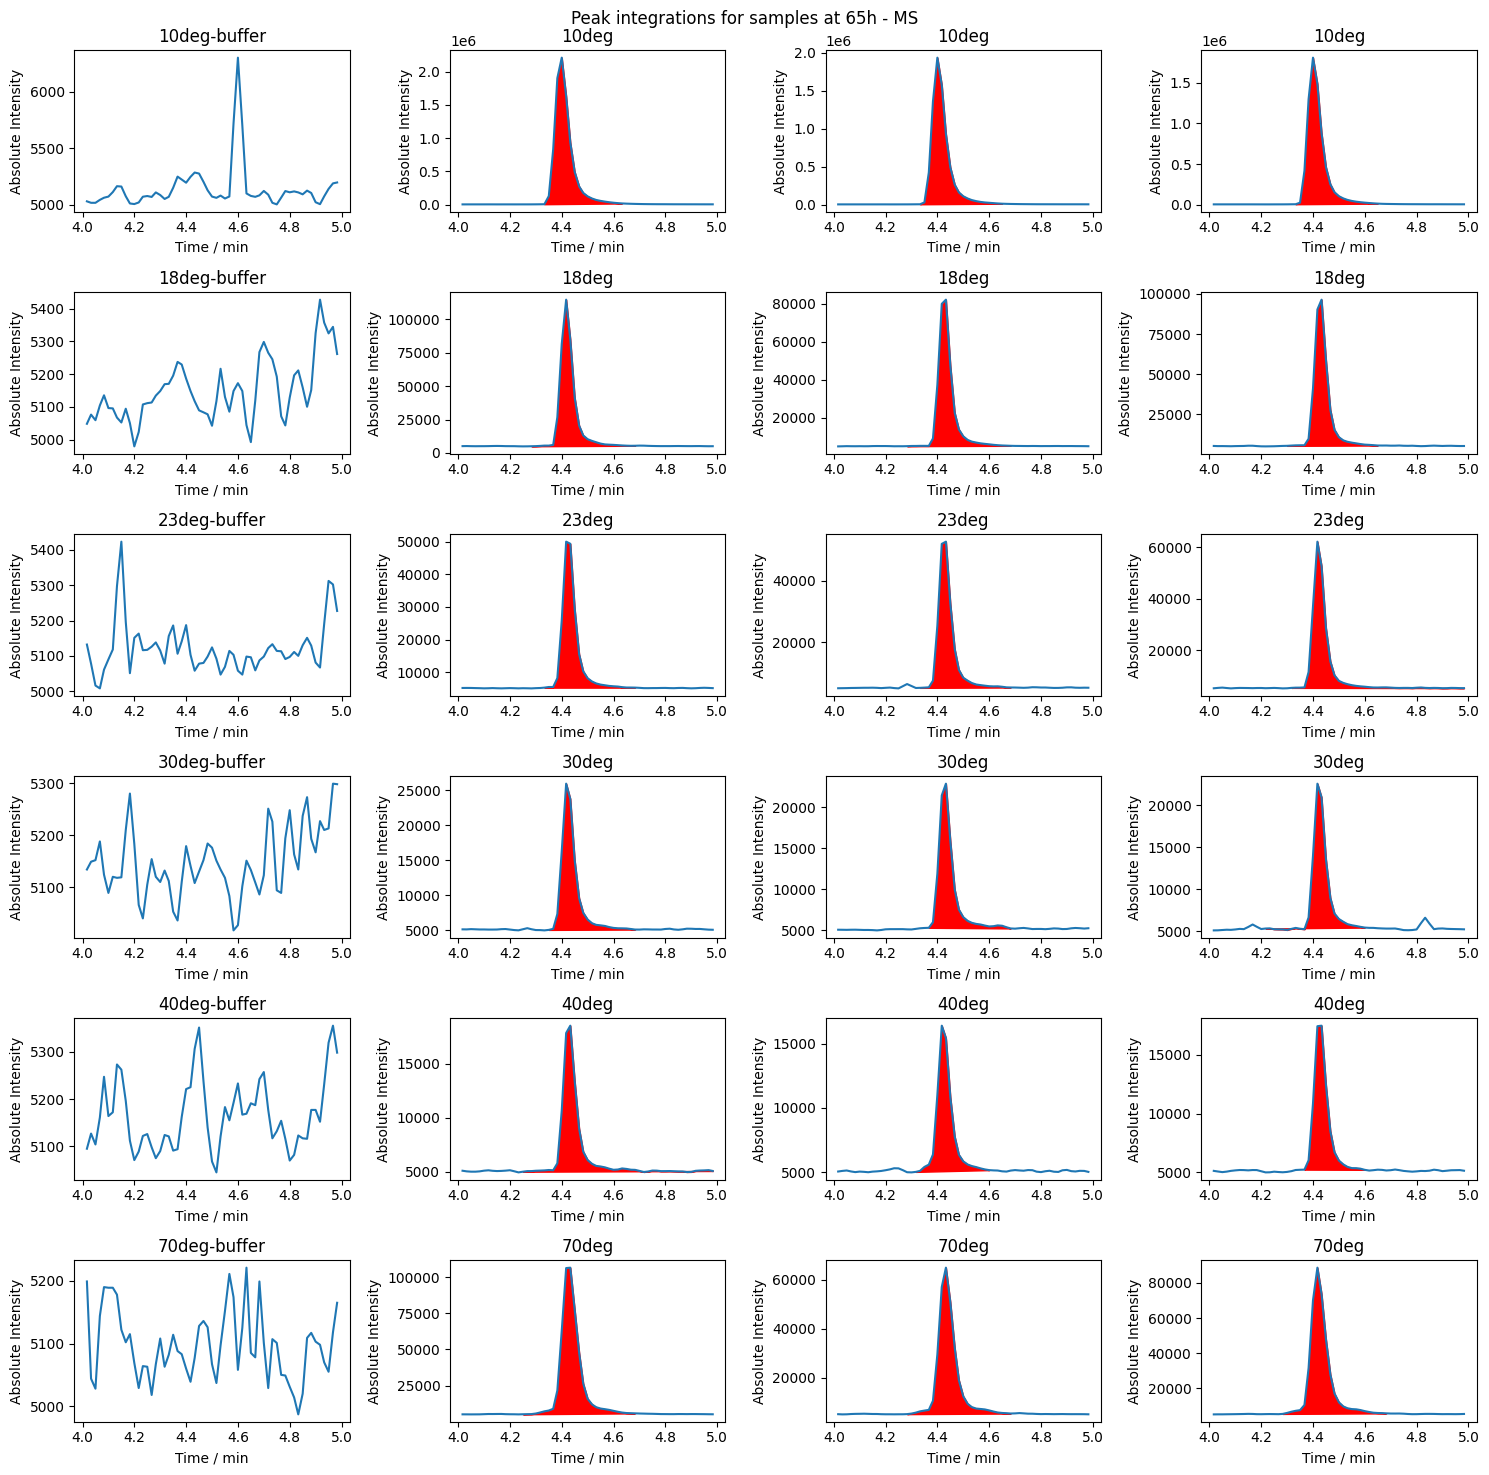

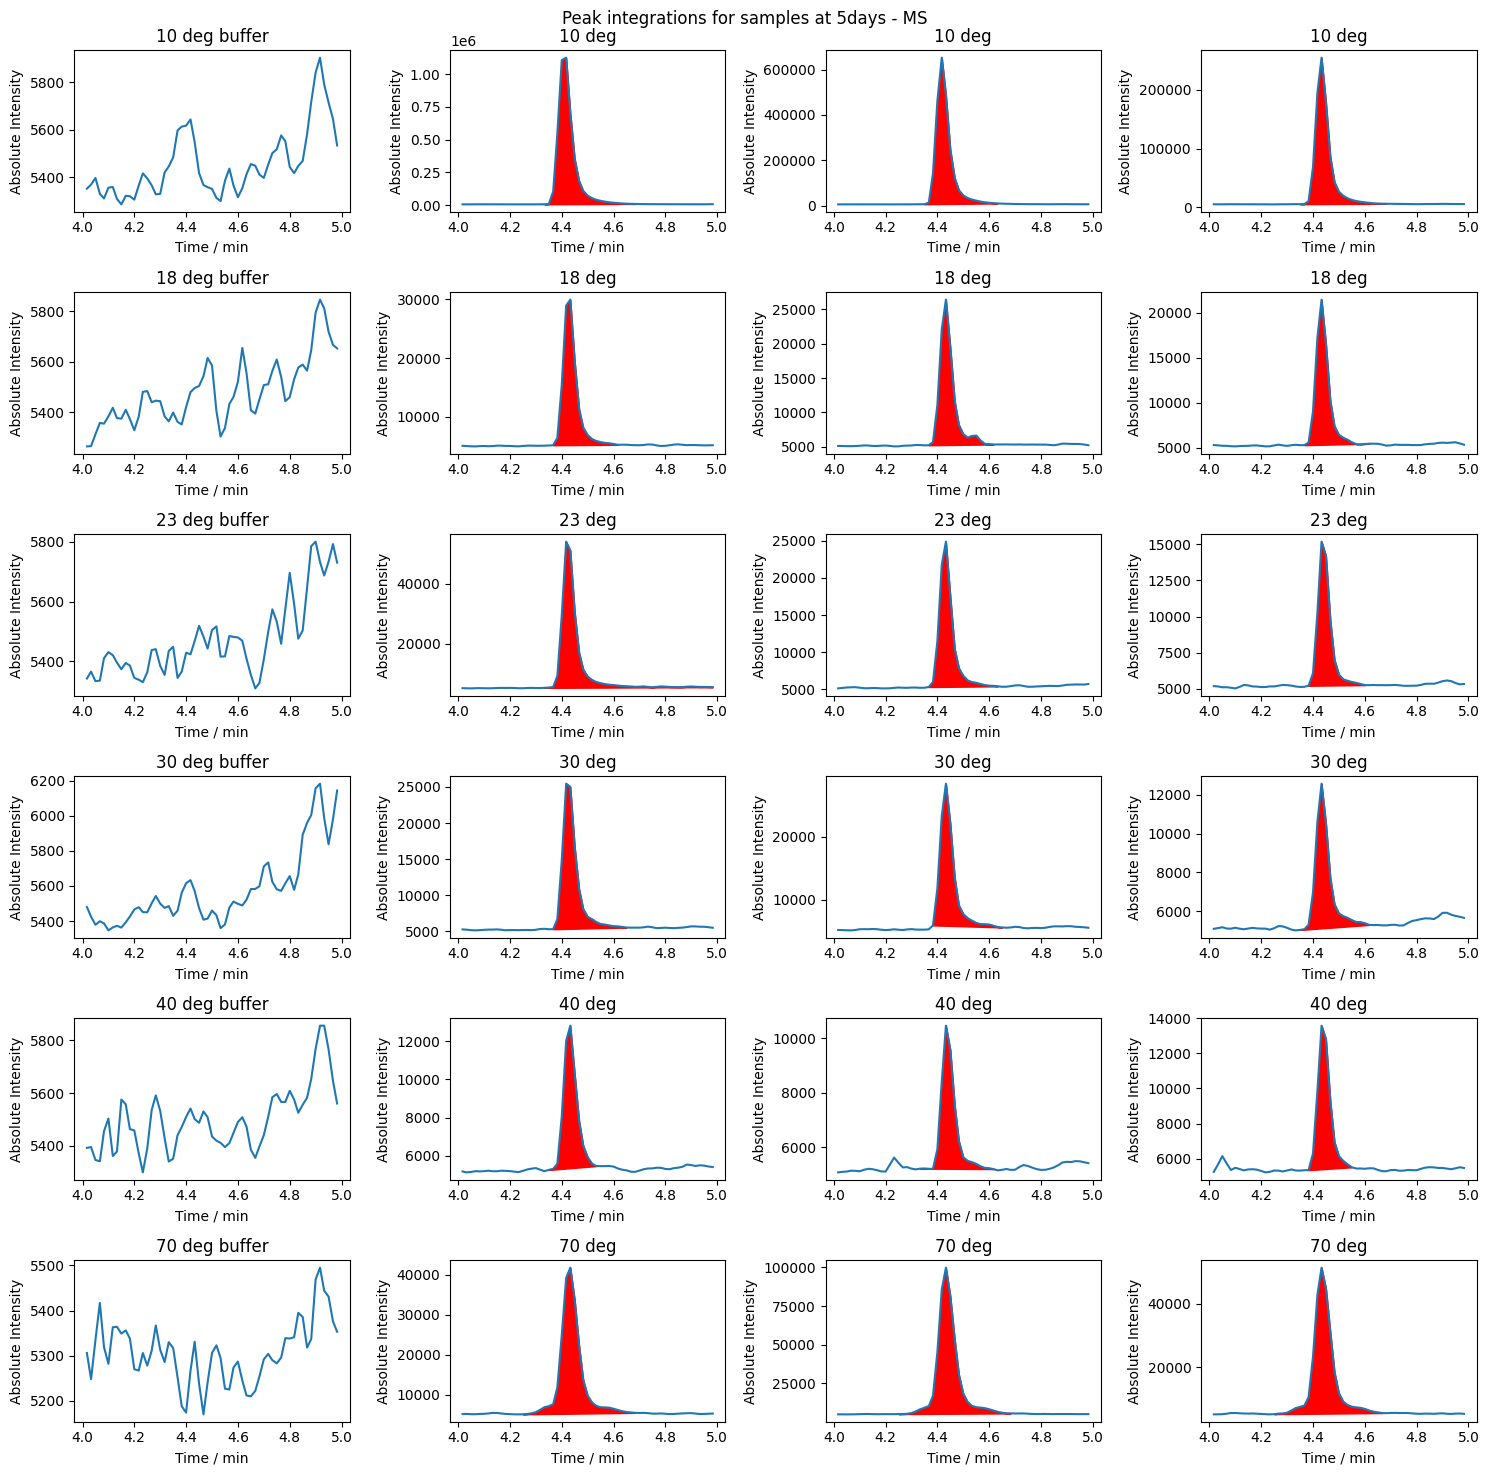

In [53]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
temp_to_row = {'10':0,
               '18':1,
               '23':2,
               '30':3,
               '40':4,
               '70':5}

for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    for time in ['65h','5days']:

        fig, axs = plt.subplots(6,4,figsize=(15,15),sharey=False)
        t_df = MS.filter(pl.col('Sample Type')=="Unknown"
         ).filter(pl.col('Data Filename').str.contains(time))
        
        for n,name in enumerate(t_df['Data Filename']):
            if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
        
                chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
                peak_start = float(MS.filter(pl.col('Data Filename')==name)['Peak Start'][0])
                peak_end = float(MS.filter(pl.col('Data Filename')==name)['Peak End'][0])
                df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                             ).filter(pl.col('Time (min)')<zoom[1])
                x=np.array([df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                       df.filter(pl.col('Time (min)')>peak_start
                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
                y=[df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
                slope, intercept = np.polyfit(x, y, 1)
                baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
                i=temp_to_row[(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][0]+
                   t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][1])]
                if time=='65h':
                    j=[0 if 'buffer' in t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0]
                    else int(t_df.filter(pl.col('Data Filename')==name)['Vial#'][0][-1])-1][0]
                if time=='5days':
                    j=[0 if 'buffer' in t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0]
                    else int(t_df.filter(pl.col('Data Filename')==name)['Vial#'][0][1:])-7][0]
                axs[i,j].plot(df['Time (min)'],
                         df['Absolute Intensity'])
                poly_collect = axs[i,j].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                                 df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                                baseline,color='red')
                paths = poly_collect.get_paths()
                area = 0
                for path in paths:
                    poly = Polygon(path.vertices)
                    area += poly.area
                areas.append(area*60) # to get it in µAbs*s as in Labsolutions
                names.append(time+' '+MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                inj_vols.append(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
                axs[i,j].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                axs[i,j].set_xlabel('Time / min')
                axs[i,j].set_ylabel('Absolute Intensity')
            else:
                chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
                df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                             ).filter(pl.col('Time (min)')<zoom[1])
                i=temp_to_row[(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][0]+
                   t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][1])]
                if time=='65h':
                    j=[0 if 'buffer' in t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0]
                    else int(t_df.filter(pl.col('Data Filename')==name)['Vial#'][0][-1])-1][0]
                if time=='5days':
                    j=[0 if 'buffer' in t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0]
                    else int(t_df.filter(pl.col('Data Filename')==name)['Vial#'][0][1:])-7][0]
                axs[i,j].plot(df['Time (min)'],
                         df['Absolute Intensity'])
                axs[i,j].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                axs[i,j].set_xlabel('Time / min')
                axs[i,j].set_ylabel('Absolute Intensity')
        plt.suptitle('Peak integrations for samples at '+time+' - MS')
        plt.tight_layout()
        plt.savefig('plots/'+project_name+'/MS integrations for samples at '+time+' -MS-zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')
    

### Calc. Conc.

In [54]:
amounts_MS= pl.DataFrame({'Sample Name':names+control_names,
                           'Area (python)':areas+control_areas,
                          'Inj. Vol.':inj_vols+control_inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_MS_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [55]:
amounts_MS

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""65h 10deg""",8.8358e6,30.0,169.783107
"""65h 10deg""",7.4357e6,30.0,142.87742
"""65h 10deg""",7.0231e6,30.0,134.946908
"""65h 18deg""",366000.366,30.0,7.010924
"""65h 18deg""",273620.376,30.0,5.235563
"""65h 18deg""",318484.365,30.0,6.097761
"""65h 23deg""",161193.03,30.0,3.074931
"""65h 23deg""",173984.748,30.0,3.320763
"""65h 23deg""",191946.996,30.0,3.665962


In [56]:
concs_MS=amounts_MS.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_MS#.filter(pl.col('Sample Name').str.contains('40')
                             #   )

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""65h 10deg""",8.8358e6,30.0,169.783107,5659.436903
"""65h 10deg""",7.4357e6,30.0,142.87742,4762.580655
"""65h 10deg""",7.0231e6,30.0,134.946908,4498.230251
"""65h 18deg""",366000.366,30.0,7.010924,233.697479
"""65h 18deg""",273620.376,30.0,5.235563,174.518773
"""65h 18deg""",318484.365,30.0,6.097761,203.258685
"""65h 23deg""",161193.03,30.0,3.074931,102.497713
"""65h 23deg""",173984.748,30.0,3.320763,110.692099
"""65h 23deg""",191946.996,30.0,3.665962,122.198731


In [57]:
corr_factor = (10000/
concs_MS.filter(pl.col('Sample Name')=="10uM ABm1-42"
                )['Conc. (nM)'][0])
corr_factor

0.9921354224372063

In [58]:
concs_MS=concs_MS.with_columns(
    (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
)

In [59]:
concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
                        ).filter(pl.col('Sample Name').str.contains('70')
                            ).filter(pl.col('Sample Name').str.contains('65h'))['Corr. Conc. (nM)'].to_numpy()

array([288.29357695, 161.42140322, 223.26736378])

In [60]:
concs_MS.filter(pl.col('Sample Name').str.contains('buffer'))
#no buffer signal

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM),Corr. Conc. (nM)
str,f64,f64,f64,f64,f64


In [61]:
temp=18
y_t1=concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)']#.to_numpy()

y_t1=y_t1.filter(y_t1>0).to_numpy()
y_t1

array([231.85954693, 173.14625662, 201.66014162])

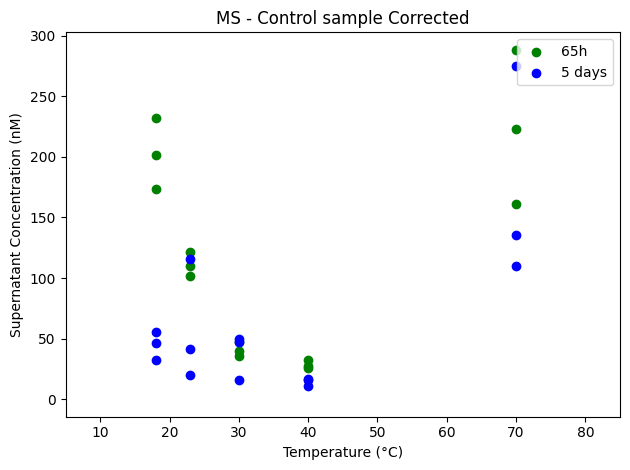

In [62]:
temps=[18,23,30,40,70]
buffer_corr_t1=[]
buffer_corr_t2=[]
temps_t1=[]
temps_t2=[]
for temp in temps:
    y_t1=concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)']#.to_numpy()
           
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    buffer_corr_t1.append(y_t1)
    temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([int(temp)]*len(y_t1),y_t1,color='green')
    
    y_t2=concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('5days')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            
    y_t2=y_t2.filter(y_t2>0).to_numpy()
    buffer_corr_t2.append(y_t2)
    temps_t2.append([int(temp)]*len(y_t2))
    
    plt.scatter([int(temp)]*len(y_t2),y_t2,color='blue')

buffer_corr_values = pl.DataFrame({'Temp':temps_t1+temps_t2,
                                           'Conc (nM)':buffer_corr_t1+buffer_corr_t2,
                                           'Incubation time (days)':[2.7]*len(temps_t1)+[5]*len(temps_t2)
                                          })
plt.scatter(0,0,color='green',label='65h')
plt.scatter(0,0,color='blue',label='5 days')
plt.xlim(5,85)
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('MS - Control sample Corrected')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/MS replicates-corr by control sample.pdf')

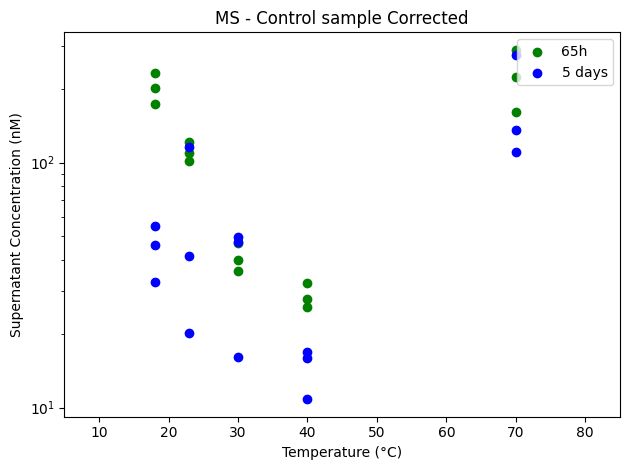

In [63]:
temps=[18,23,30,40,70]
buffer_corr_t1=[]
buffer_corr_t2=[]
temps_t1=[]
temps_t2=[]
for temp in temps:
    y_t1=concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('65h')
                                        )['Corr. Conc. (nM)']#.to_numpy()
           
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    buffer_corr_t1.append(y_t1)
    temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([int(temp)]*len(y_t1),y_t1,color='green')
    
    y_t2=concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
                            ).filter(pl.col('Sample Name').str.contains(temp)
                                ).filter(pl.col('Sample Name').str.contains('5days')
                                        )['Corr. Conc. (nM)']#.to_numpy()
            
    y_t2=y_t2.filter(y_t2>0).to_numpy()
    buffer_corr_t2.append(y_t2)
    temps_t2.append([int(temp)]*len(y_t2))
    
    plt.scatter([int(temp)]*len(y_t2),y_t2,color='blue')

values = pl.DataFrame({'Temp':temps_t1+temps_t2,
                                           'Conc (nM)':buffer_corr_t1+buffer_corr_t2,
                                           'Incubation time (days)':[2.7]*len(temps_t1)+[5]*len(temps_t2)
                                          })
plt.scatter(0,0,color='green',label='65h')
plt.scatter(0,0,color='blue',label='5 days')
plt.xlim(5,85)
plt.semilogy()
plt.legend()
plt.xlabel('Temperature (°C)')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('MS - Control sample Corrected')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/MS replicates-corr by control sample-log.pdf')

In [64]:
values_eq = values.explode(['Temp','Conc (nM)']
          ).filter(~((pl.col('Temp')<30) & (pl.col('Incubation time (days)')<3))
                  ) # remove early timepoint of two lowest temperatures, as they don't seem to have reached equilibrium
values_eq

Temp,Conc (nM),Incubation time (days)
i64,f64,f64
30,47.156498,2.7
30,39.957779,2.7
30,36.050869,2.7
40,32.284052,2.7
40,25.676165,2.7
40,27.625397,2.7
70,288.293577,2.7
70,161.421403,2.7
70,223.267364,2.7


In [65]:
values_eq.write_csv('Processed data/'+project_name+'/MS values 260122.csv')